# FabGuard — TG KPI 데이터 라벨링

`sim_csv_out/kpi_toolgroup.csv` (long format) 를 불러와 확인합니다.

| 파일 | 크기 | 로드 |
|------|------|------|
| `kpi_toolgroup.csv` | ~200MB | **전체 로드 OK** |
| `kpi_tool.csv` | ~5GB | 이 노트북 후반 — **chunk만** (별도 셀) |

**커널:** 반드시 **`FAB_BEAR simulation`** (또는 `FAB_BEAR/simulation/.venv`) 선택.  
기본 `Python 3` 는 venv가 아니라 pandas 없을 수 있음.

**커널 cwd:** `FAB_BEAR/simulation/ML` 기준 (`../sim_csv_out/...`)

**한글 차트:** `ML/fonts/NanumGothic-*.ttf` (또는 `brew install --cask font-nanum-gothic`) — §0 경로 셀에서 matplotlib에 등록.

In [1]:
import sys
print("Python:", sys.executable)
assert "FAB_BEAR/simulation/.venv" in sys.executable.replace("\\", "/"), (
    "venv 커널이 아닙니다. 우측 상단 → Select Kernel → FAB_BEAR simulation"
)
import pandas as pd
print("pandas", pd.__version__)

Python: /Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simulation/.venv/bin/python
pandas 3.0.3


In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from matplotlib import font_manager, rcParams

# simulation/ML → simulation/sim_csv_out
ML_DIR = Path(".").resolve()
SIM_DIR = ML_DIR.parent
CSV_DIR = SIM_DIR / "sim_csv_out"
TG_PATH = CSV_DIR / "kpi_toolgroup.csv"
TOOL_PATH = CSV_DIR / "kpi_tool.csv"

assert TG_PATH.is_file(), f"없음: {TG_PATH} — 시뮬 후 sim_csv_out 을 확인하세요."


def setup_nanum_gothic() -> str:
    """Register NanumGothic for matplotlib (project fonts/ or ~/Library/Fonts)."""
    candidates = [
        ML_DIR / "fonts" / "NanumGothic-Regular.ttf",
        Path.home() / "Library" / "Fonts" / "NanumGothic-Regular.ttf",
    ]
    for font_path in candidates:
        if font_path.is_file():
            font_manager.fontManager.addfont(str(font_path))
            name = font_manager.FontProperties(fname=str(font_path)).get_name()
            rcParams["font.family"] = name
            rcParams["axes.unicode_minus"] = False
            return name
    raise FileNotFoundError(
        "NanumGothic-Regular.ttf not found. "
        "Install: brew install --cask font-nanum-gothic "
        "or place TTF under simulation/ML/fonts/"
    )


MATPLOTLIB_FONT = setup_nanum_gothic()

print("SIM_DIR:", SIM_DIR)
print("TG KPI:", TG_PATH.name, f"({TG_PATH.stat().st_size / 1e6:.1f} MB)")
print("matplotlib font:", MATPLOTLIB_FONT)

SIM_DIR: /Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simulation
TG KPI: kpi_toolgroup.csv (222.9 MB)
matplotlib font: NanumGothic


## 1) TG KPI — 스키마 미리보기 (앞 50행)

long format: 한 행 = `(run_id, snapshot_time, scope=toolgroup, kpi_name)` 당 `value` 1개.

In [3]:
peek = pd.read_csv(TG_PATH, nrows=50)
display(peek.head(20))
print("columns:", list(peek.columns))
print("kpi_name:", sorted(peek["kpi_name"].unique()))
print("scope 예 (toolgroup):", peek["scope"].iloc[0])
print("run_id:", peek["run_id"].unique()[:3])

,run_id,snapshot_time,scope,kpi_name,value,window_minutes,numerator,denominator,meta
0,ece173272af7,60.0,DE_BE_11,available_tool_ratio,1.0,NaN,11.0,11.0,NaN
1,ece173272af7,60.0,DE_BE_11,wip,0.0,NaN,0.0,0.0,NaN
2,ece173272af7,60.0,DE_BE_11,q_time_min,0.0,NaN,0.0,0.0,NaN
3,ece173272af7,60.0,DE_BE_11,wait_ratio,0.0,NaN,0.0,11.0,NaN
4,ece173272af7,60.0,DE_BE_12,available_tool_ratio,1.0,NaN,10.0,10.0,NaN
5,ece173272af7,60.0,DE_BE_12,wip,0.0,NaN,0.0,0.0,NaN
6,ece173272af7,60.0,DE_BE_12,q_time_min,0.0,NaN,0.0,0.0,NaN
7,ece173272af7,60.0,DE_BE_12,wait_ratio,0.0,NaN,0.0,10.0,NaN
8,ece173272af7,60.0,DE_BE_13,available_tool_ratio,1.0,NaN,23.0,23.0,NaN
9,ece173272af7,60.0,DE_BE_13,wip,0.0,NaN,0.0,0.0,NaN


columns: ['run_id', 'snapshot_time', 'scope', 'kpi_name', 'value', 'window_minutes', 'numerator', 'denominator', 'meta']
kpi_name: ['available_tool_ratio', 'q_time_min', 'wait_ratio', 'wip']
scope 예 (toolgroup): DE_BE_11
run_id: <StringArray>
['ece173272af7']
Length: 1, dtype: str


## 2) TG KPI — 전체 로드

~300만 행 long / pivot 후 ~54만 행 wide. RAM 여유 있으면 아래 셀 실행.

In [4]:
tg_long = pd.read_csv(
    TG_PATH,
    usecols=["snapshot_time", "scope", "kpi_name", "value", "window_minutes"],
)
tg_long = tg_long.rename(columns={"scope": "toolgroup"})
tg_long["snapshot_time"] = tg_long["snapshot_time"].astype(float)

print("tg_long shape:", tg_long.shape)
print("snapshot_time:", tg_long["snapshot_time"].min(), "→", tg_long["snapshot_time"].max())
print("toolgroups:", tg_long["toolgroup"].nunique())
print("kpi counts:\n", tg_long["kpi_name"].value_counts())
tg_long.head()

tg_long shape: (3323736, 5)
snapshot_time: 60.0 → 313560.0
toolgroups: 106
kpi counts:
 kpi_name
available_tool_ratio    553956
wip                     553956
q_time_min              553956
wait_ratio              553956
utilization_avg         553956
setup_ratio_avg         553956
Name: count, dtype: int64


,snapshot_time,toolgroup,kpi_name,value,window_minutes
0,60.0,DE_BE_11,available_tool_ratio,1.0,NaN
1,60.0,DE_BE_11,wip,0.0,NaN
2,60.0,DE_BE_11,q_time_min,0.0,NaN
3,60.0,DE_BE_11,wait_ratio,0.0,NaN
4,60.0,DE_BE_12,available_tool_ratio,1.0,NaN


## 3) TG KPI — wide pivot (분석·라벨링용)

한 행 = `(snapshot_time, toolgroup)` + KPI 컬럼. (CSV에 run이 하나면 `run_id` 생략 OK)

In [5]:
TG_INSTANT = ("q_time_min", "wait_ratio", "wip", "available_tool_ratio")
TG_UTIL = ("utilization_avg", "setup_ratio_avg")

instant = tg_long[tg_long["window_minutes"].isna() | (tg_long["window_minutes"] == "")]
instant = instant[instant["kpi_name"].isin(TG_INSTANT)]
tg_wide = instant.pivot_table(
    index=["snapshot_time", "toolgroup"],
    columns="kpi_name",
    values="value",
    aggfunc="first",
).reset_index()

util = tg_long[tg_long["kpi_name"].isin(TG_UTIL)]
tg_wide_util = util.pivot_table(
    index=["snapshot_time", "toolgroup"],
    columns="kpi_name",
    values="value",
    aggfunc="first",
).reset_index()

tg_wide = tg_wide.merge(
    tg_wide_util,
    on=["snapshot_time", "toolgroup"],
    how="outer",
)

print("tg_wide shape:", tg_wide.shape)
print("columns:", list(tg_wide.columns))
tg_wide.head(20)

tg_wide shape: (553956, 8)
columns: ['snapshot_time', 'toolgroup', 'available_tool_ratio', 'q_time_min', 'wait_ratio', 'wip', 'setup_ratio_avg', 'utilization_avg']


kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg
0,60.0,DE_BE_11,1.0,0.0,0.0,0.0,0.0,0.0
1,60.0,DE_BE_12,1.0,0.0,0.0,0.0,0.0,0.0
2,60.0,DE_BE_13,1.0,0.0,0.0,0.0,0.0,0.0
3,60.0,DE_BE_48,1.0,0.0,0.0,0.0,0.0,0.0
4,60.0,DE_BE_50,1.0,0.0,0.0,0.0,0.0,0.0
5,60.0,DE_BE_65,1.0,0.0,0.0,0.0,0.0,0.0
6,60.0,DE_BE_66,1.0,0.0,0.0,0.0,0.0,0.0
7,60.0,DE_BE_67,1.0,0.0,0.0,0.0,0.0,0.0
8,60.0,DE_BE_69,1.0,0.0,0.0,0.0,0.0,0.0
9,60.0,DE_FE_1,1.0,0.0,0.0,0.0,0.0,0.0


## 4) Tool KPI → TG별 max (chunk) 후 `tg_wide`에 merge

`kpi_tool.csv` (~5GB)는 **전체 read 금지**. 필요한 KPI만 chunk로 읽고  
`(snapshot_time, toolgroup)` 기준 `max(utilization)`, `max(avg_q_time)` 만 남깁니다 (~54만 행 → `tg_wide`와 동일 grain).

**merge 키:** `snapshot_time` + `toolgroup` (run_id 없을 때와 동일)

In [6]:
def tool_id_to_toolgroup(tool_id: str) -> str:
    return tool_id.rsplit("#", 1)[0] if "#" in tool_id else tool_id


TOOL_KPIS = {"utilization": "max_util", "avg_q_time": "max_avg_q_time"}
CHUNKSIZE = 2_000_000

parts = []
reader = pd.read_csv(
    TOOL_PATH,
    chunksize=CHUNKSIZE,
    usecols=["snapshot_time", "scope", "kpi_name", "value"],
)
for i, chunk in enumerate(reader):
    chunk = chunk[chunk["kpi_name"].isin(TOOL_KPIS.keys())]
    if chunk.empty:
        continue
    chunk["toolgroup"] = chunk["scope"].map(tool_id_to_toolgroup)
    chunk["snapshot_time"] = chunk["snapshot_time"].astype(float)
    g = chunk.groupby(["snapshot_time", "toolgroup", "kpi_name"], as_index=False)["value"].max()
    parts.append(g)
    print(f"chunk {i+1}: kept {len(chunk):,} rows")

tool_combined = pd.concat(parts, ignore_index=True)
tool_combined = tool_combined.groupby(
    ["snapshot_time", "toolgroup", "kpi_name"], as_index=False
)["value"].max()

tool_agg = tool_combined.pivot(
    index=["snapshot_time", "toolgroup"], columns="kpi_name", values="value"
).reset_index()
tool_agg = tool_agg.rename(columns=TOOL_KPIS)

print("tool_agg shape:", tool_agg.shape)
tool_agg.head()

chunk 1: kept 444,621 rows
chunk 2: kept 444,621 rows
chunk 3: kept 444,568 rows
chunk 4: kept 444,091 rows
chunk 5: kept 444,436 rows
chunk 6: kept 444,621 rows
chunk 7: kept 444,621 rows
chunk 8: kept 444,224 rows
chunk 9: kept 444,250 rows
chunk 10: kept 444,621 rows
chunk 11: kept 444,621 rows
chunk 12: kept 444,410 rows
chunk 13: kept 444,091 rows
chunk 14: kept 444,594 rows
chunk 15: kept 444,620 rows
chunk 16: kept 444,596 rows
chunk 17: kept 444,092 rows
chunk 18: kept 444,407 rows
chunk 19: kept 444,621 rows
chunk 20: kept 444,621 rows
chunk 21: kept 444,253 rows
chunk 22: kept 444,221 rows
chunk 23: kept 444,621 rows
chunk 24: kept 444,621 rows
chunk 25: kept 444,438 rows
chunk 26: kept 444,092 rows
chunk 27: kept 444,565 rows
chunk 28: kept 444,621 rows
chunk 29: kept 444,621 rows
chunk 30: kept 444,095 rows
chunk 31: kept 444,379 rows
chunk 32: kept 444,621 rows
chunk 33: kept 444,620 rows
chunk 34: kept 444,281 rows
chunk 35: kept 444,194 rows
chunk 36: kept 444,620 rows
c

kpi_name,snapshot_time,toolgroup,max_avg_q_time,max_util
0,60.0,DE_BE_11,0.0,0.0
1,60.0,DE_BE_12,0.0,0.0
2,60.0,DE_BE_13,0.0,0.0
3,60.0,DE_BE_48,0.0,0.0
4,60.0,DE_BE_50,0.0,0.0


In [7]:
# tg_wide 와 merge (키: snapshot_time + toolgroup)
wide = tg_wide.merge(tool_agg, on=["snapshot_time", "toolgroup"], how="left")
n_miss = wide["max_util"].isna().sum()
wide["max_util"] = wide["max_util"].fillna(0.0)
wide["max_avg_q_time"] = wide["max_avg_q_time"].fillna(0.0)

print("wide shape:", wide.shape)
print("rows with no matching tool_agg (filled 0):", n_miss)

# 메모리 여유 시: del tg_long

wide.head(108)

wide shape: (553956, 10)
rows with no matching tool_agg (filled 0): 0


kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg,max_avg_q_time,max_util
0,60.0,DE_BE_11,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,60.0,DE_BE_12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60.0,DE_BE_13,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,60.0,DE_BE_48,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60.0,DE_BE_50,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
103,60.0,WE_FE_83,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,60.0,WE_FE_84,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,60.0,WE_FE_85,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,120.0,DE_BE_11,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5) 라벨·임계값 튜닝용 — KPI 분포 EDA

`wide` 기준으로 아래 지표의 **전역 분포**(히스토그램 + 박스)와 **요약 통계**를 봅니다.

- `low_avail`에 해당하는 값은 CSV 컬럼명이 **`available_tool_ratio`** 입니다. (값이 **낮을수록** 가용이 나쁨)

In [8]:
# §5-0) wide KPI 결측치 점검
assert "wide" in dir() and isinstance(wide, pd.DataFrame), "먼저 §4까지 실행해 wide DataFrame 을 만드세요."

KPI_COLS = [
    "available_tool_ratio",
    "q_time_min",
    "wait_ratio",
    "wip",
    "setup_ratio_avg",
    "utilization_avg",
    "max_avg_q_time",
    "max_util",
]

missing_cols = [c for c in KPI_COLS if c not in wide.columns]
if missing_cols:
    raise KeyError(f"wide 에 없는 KPI 컬럼: {missing_cols}")

n_rows = len(wide)
X_kpi = wide[KPI_COLS].apply(pd.to_numeric, errors="coerce")

miss = X_kpi.isna().sum().rename("missing_count")
miss_pct = (miss / n_rows * 100).round(4).rename("missing_pct")
non_numeric = (wide[KPI_COLS].apply(pd.to_numeric, errors="coerce").isna() & wide[KPI_COLS].notna()).sum().rename(
    "coerce_failed"
)

miss_summary = pd.concat([miss, miss_pct, non_numeric], axis=1)
miss_summary["present_pct"] = (100 - miss_summary["missing_pct"]).round(4)
display(miss_summary.sort_values("missing_count", ascending=False))

any_miss = X_kpi.isna().any(axis=1)
print(f"wide rows: {n_rows:,}")
print(f"rows with ≥1 KPI missing: {any_miss.sum():,} ({100 * any_miss.mean():.4f}%)")
print(f"rows with all KPI present: {(~any_miss).sum():,}")

if any_miss.any():
    sample = wide.loc[any_miss, ["snapshot_time", "toolgroup", *KPI_COLS]].head(10)
    display(sample)

# tool merge(§4) 유래 컬럼만 별도 확인
tool_merge_cols = ["max_util", "max_avg_q_time"]
tool_miss = X_kpi[tool_merge_cols].isna().any(axis=1)
print(
    f"rows missing max_util and/or max_avg_q_time (tool chunk merge): "
    f"{tool_miss.sum():,} ({100 * tool_miss.mean():.4f}%)"
)

,missing_count,missing_pct,coerce_failed,present_pct
kpi_name,,,,
available_tool_ratio,0,0.0,0,100.0
q_time_min,0,0.0,0,100.0
wait_ratio,0,0.0,0,100.0
wip,0,0.0,0,100.0
setup_ratio_avg,0,0.0,0,100.0
utilization_avg,0,0.0,0,100.0
max_avg_q_time,0,0.0,0,100.0
max_util,0,0.0,0,100.0


wide rows: 553,956
rows with ≥1 KPI missing: 0 (0.0000%)
rows with all KPI present: 553,956
rows missing max_util and/or max_avg_q_time (tool chunk merge): 0 (0.0000%)


상수 컬럼(heatmap 제외): ['setup_ratio_avg'] 
  → 전 행 값이 동일해 상관관계를 정의할 수 없습니다. 
  → setup_ratio_avg 는 TG instant KPI에서 0인 경우가 많아 흔합니다.


/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_90438/1969827166.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


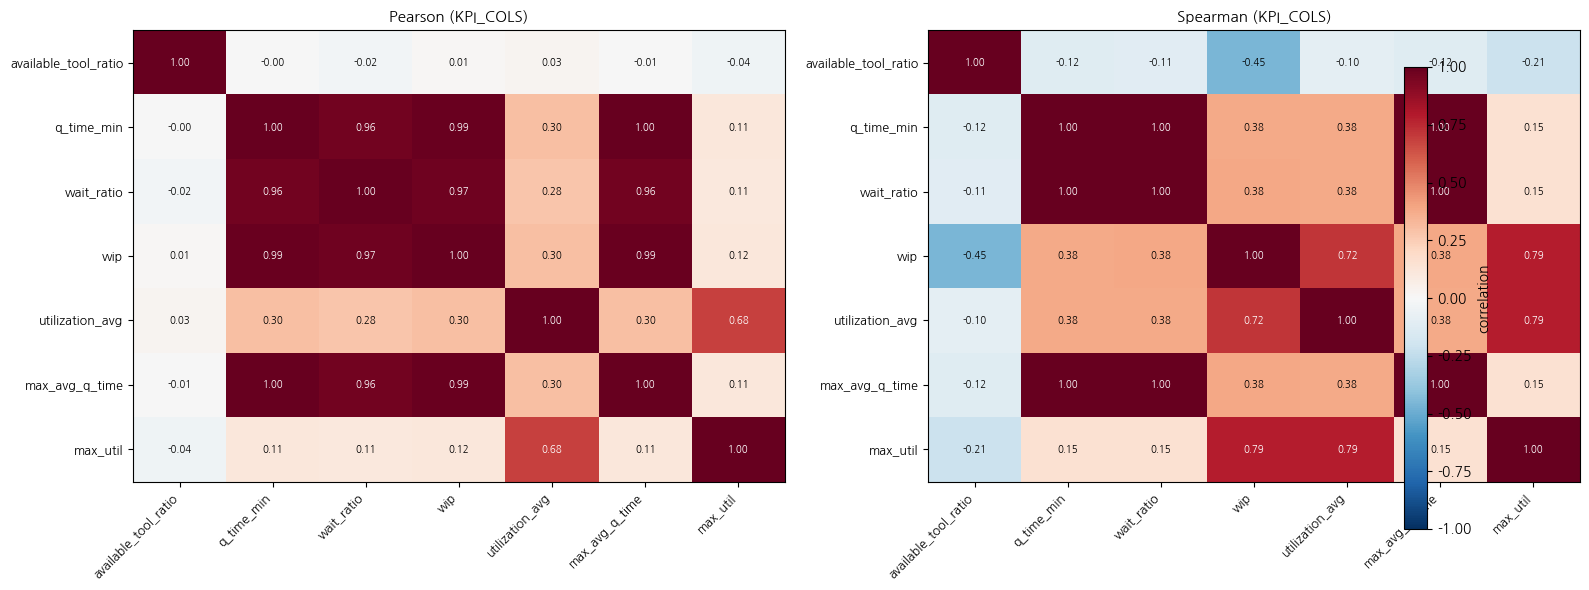

Top |Pearson| pairs:


,col_a,col_b,corr,abs_corr
9,q_time_min,max_avg_q_time,0.9997,0.9997
16,wip,max_avg_q_time,0.9892,0.9892
7,q_time_min,wip,0.9889,0.9889
11,wait_ratio,wip,0.9725,0.9725
13,wait_ratio,max_avg_q_time,0.9621,0.9621
6,q_time_min,wait_ratio,0.9616,0.9616
19,utilization_avg,max_util,0.6846,0.6846
18,utilization_avg,max_avg_q_time,0.3004,0.3004
8,q_time_min,utilization_avg,0.2977,0.2977
15,wip,utilization_avg,0.2974,0.2974


In [9]:
# §5-1) KPI_COLS 상관관계 — heatmap
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

assert "KPI_COLS" in dir() and "wide" in dir(), "먼저 §5-0 셀을 실행하세요."

corr_df = wide[KPI_COLS].apply(pd.to_numeric, errors="coerce").copy()

# 분산이 없는(값이 하나뿐) 컬럼 → 상관계수 NaN. 오류가 아니라 안내 메시지.
nunique = corr_df.nunique(dropna=True)
constant_cols = nunique[nunique <= 1].index.tolist()
active_cols = [c for c in KPI_COLS if c not in constant_cols]
if constant_cols:
    print(
        "상수 컬럼(heatmap 제외):",
        constant_cols,
        "\n  → 전 행 값이 동일해 상관관계를 정의할 수 없습니다.",
        "\n  → setup_ratio_avg 는 TG instant KPI에서 0인 경우가 많아 흔합니다.",
    )

corr_active = corr_df[active_cols]
pearson_corr = corr_active.corr(method="pearson")
spearman_corr = corr_active.corr(method="spearman")


def plot_corr_heatmap(corr_mat: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    """색상 heatmap + 셀 안에 상관계수 숫자."""
    n = len(corr_mat)
    data = corr_mat.values.astype(float)
    im = ax.imshow(data, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(corr_mat.index, fontsize=9)
    ax.set_title(title, fontsize=11)
    # 숫자 라벨
    for i in range(n):
        for j in range(n):
            v = data[i, j]
            if np.isnan(v):
                txt = "—"
            else:
                txt = f"{v:.2f}"
            color = "white" if abs(v) > 0.55 else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=color)
    return im


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = plot_corr_heatmap(pearson_corr, "Pearson (KPI_COLS)", axes[0])
im1 = plot_corr_heatmap(spearman_corr, "Spearman (KPI_COLS)", axes[1])
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cbar.set_label("correlation")
plt.tight_layout()
plt.show()

# 참고: 상위 상관 쌍 (표는 접기 — 필요 시 아래 주석 해제)
def top_corr_pairs(corr_mat: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    cols = corr_mat.columns
    pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = corr_mat.iloc[i, j]
            if pd.notna(v):
                pairs.append((cols[i], cols[j], float(v), abs(float(v))))
    return (
        pd.DataFrame(pairs, columns=["col_a", "col_b", "corr", "abs_corr"])
        .sort_values("abs_corr", ascending=False)
        .head(top_n)
    )

print("Top |Pearson| pairs:")
display(top_corr_pairs(pearson_corr, top_n=10).round(4))

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# wide 가 없으면 위 셀부터 실행
assert "wide" in dir() and isinstance(wide, pd.DataFrame), "먼저 wide DataFrame 을 만드세요."

EDA_COLS = [
    "q_time_min",
    "wait_ratio",
    "wip",
    "available_tool_ratio",  # low_avail 규칙: 이 값이 낮을수록 나쁨
    "utilization_avg",
    "max_util",
    "max_avg_q_time",
]
missing = [c for c in EDA_COLS if c not in wide.columns]
if missing:
    raise ValueError(f"wide 에 없는 컬럼: {missing}")

X = wide[EDA_COLS].apply(pd.to_numeric, errors="coerce")

# 요약 통계 (NaN 제외)
desc = X.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.97, 0.99]).T
desc["zeros_pct"] = (X == 0).mean() * 100
desc["neg_count"] = (X < 0).sum()
display(desc.round(4))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,97%,99%,max,zeros_pct,neg_count
kpi_name,,,,,,,,,,,,,,,
q_time_min,553956.0,307.5612,2515.7149,0.0,0.0,0.00,0.0000,0.0000,0.0000,183.8479,980.9548,10447.7185,42610.1512,90.8108,0
wait_ratio,553956.0,25.0415,220.0610,0.0,0.0,0.00,0.0000,0.0000,0.0000,1.0000,4.5000,1043.5000,6466.0000,90.8108,0
wip,553956.0,49.0679,400.4710,0.0,0.0,0.00,0.0000,1.0000,4.0000,22.0000,44.0000,1978.4500,6555.0000,35.3985,0
available_tool_ratio,553956.0,0.9516,0.1086,0.0,0.5,0.75,0.9524,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1883,0
utilization_avg,553956.0,0.2275,0.2655,0.0,0.0,0.00,0.0000,0.1394,0.3574,0.8557,0.9476,0.9813,1.0000,32.9730,0
max_util,553956.0,0.5481,0.4360,0.0,0.0,0.00,0.0000,0.7027,0.9955,1.0000,1.0000,1.0000,1.0000,32.9730,0
max_avg_q_time,553956.0,315.1262,2548.7825,0.0,0.0,0.00,0.0000,0.0000,0.0000,222.1322,1062.9416,10828.9401,42726.0976,90.8108,0


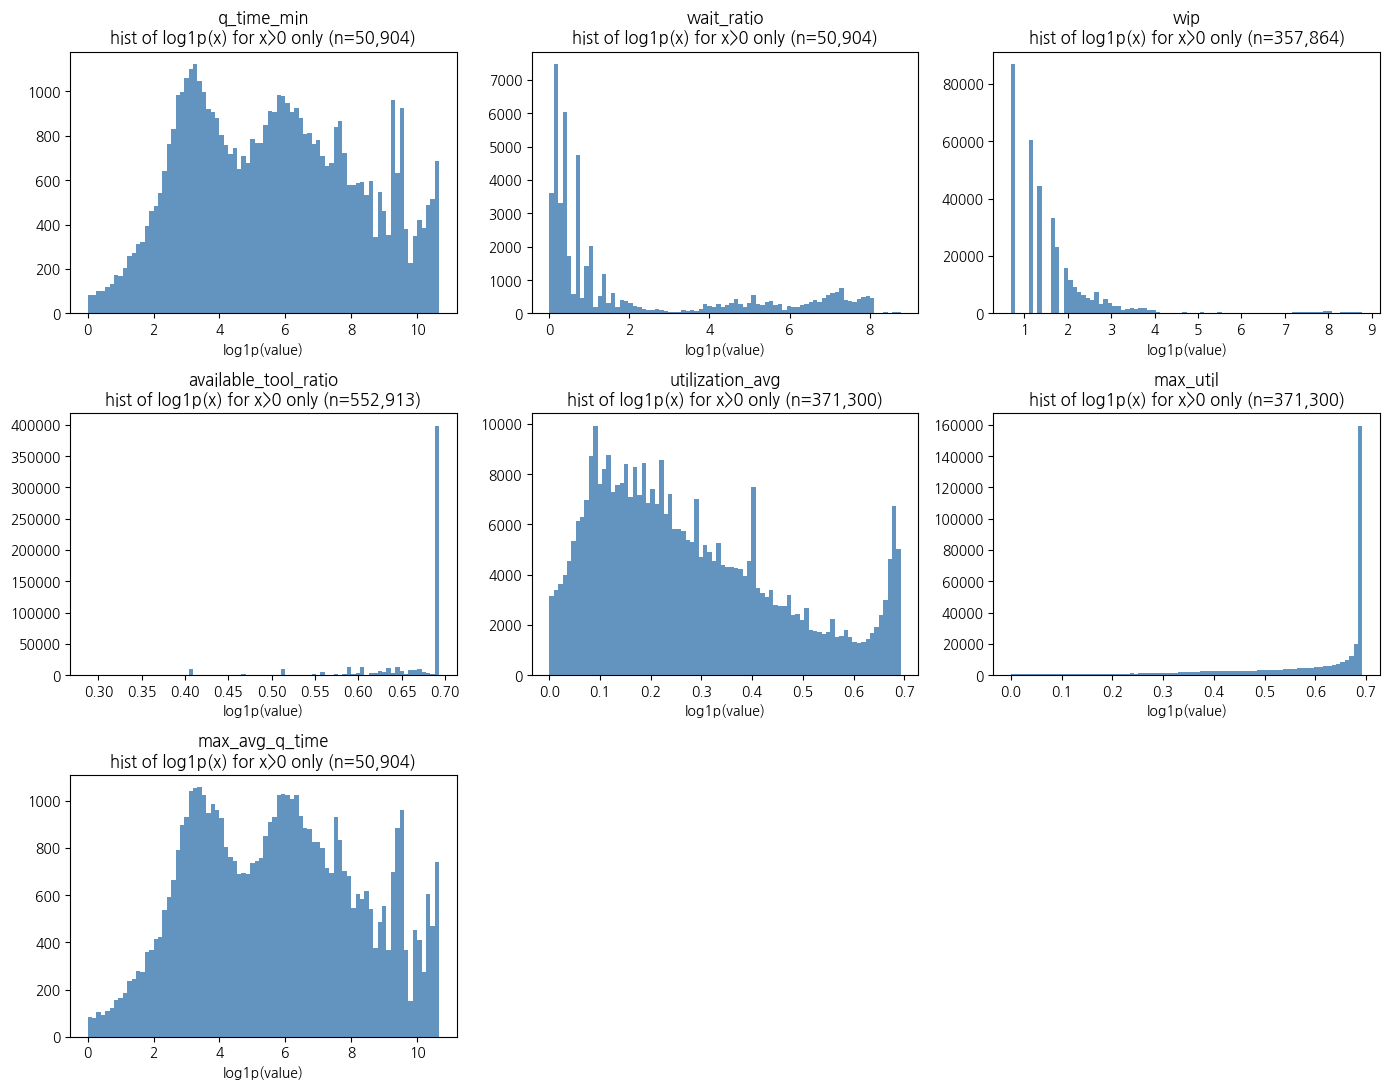

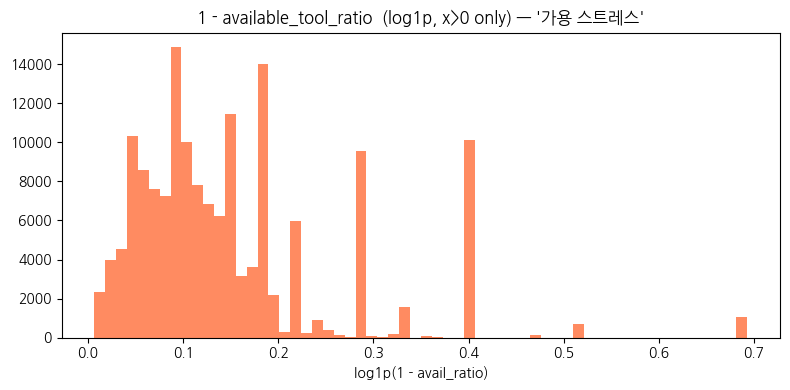

In [11]:
# 히스토그램 (log1p: 0 많고 꼬리 긴 변수용)
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for ax, col in zip(axes, EDA_COLS):
    s = X[col].dropna()
    s_pos = s[s > 0]
    if len(s_pos) > 0:
        ax.hist(np.log1p(s_pos), bins=80, color="steelblue", alpha=0.85, edgecolor="none")
        ax.set_title(f"{col}\nhist of log1p(x) for x>0 only (n={len(s_pos):,})")
        ax.set_xlabel("log1p(value)")
    else:
        ax.text(0.5, 0.5, "no positive values", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(col)
for j in range(len(EDA_COLS), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# 가용 '나쁨' 관점: 1 - available_tool_ratio
low_stress = (1.0 - X["available_tool_ratio"]).clip(lower=0, upper=1)
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.hist(np.log1p(low_stress[low_stress > 0]), bins=60, color="coral", alpha=0.9, edgecolor="none")
ax3.set_title("1 - available_tool_ratio  (log1p, x>0 only) — '가용 스트레스'")
ax3.set_xlabel("log1p(1 - avail_ratio)")
plt.tight_layout()
plt.show()

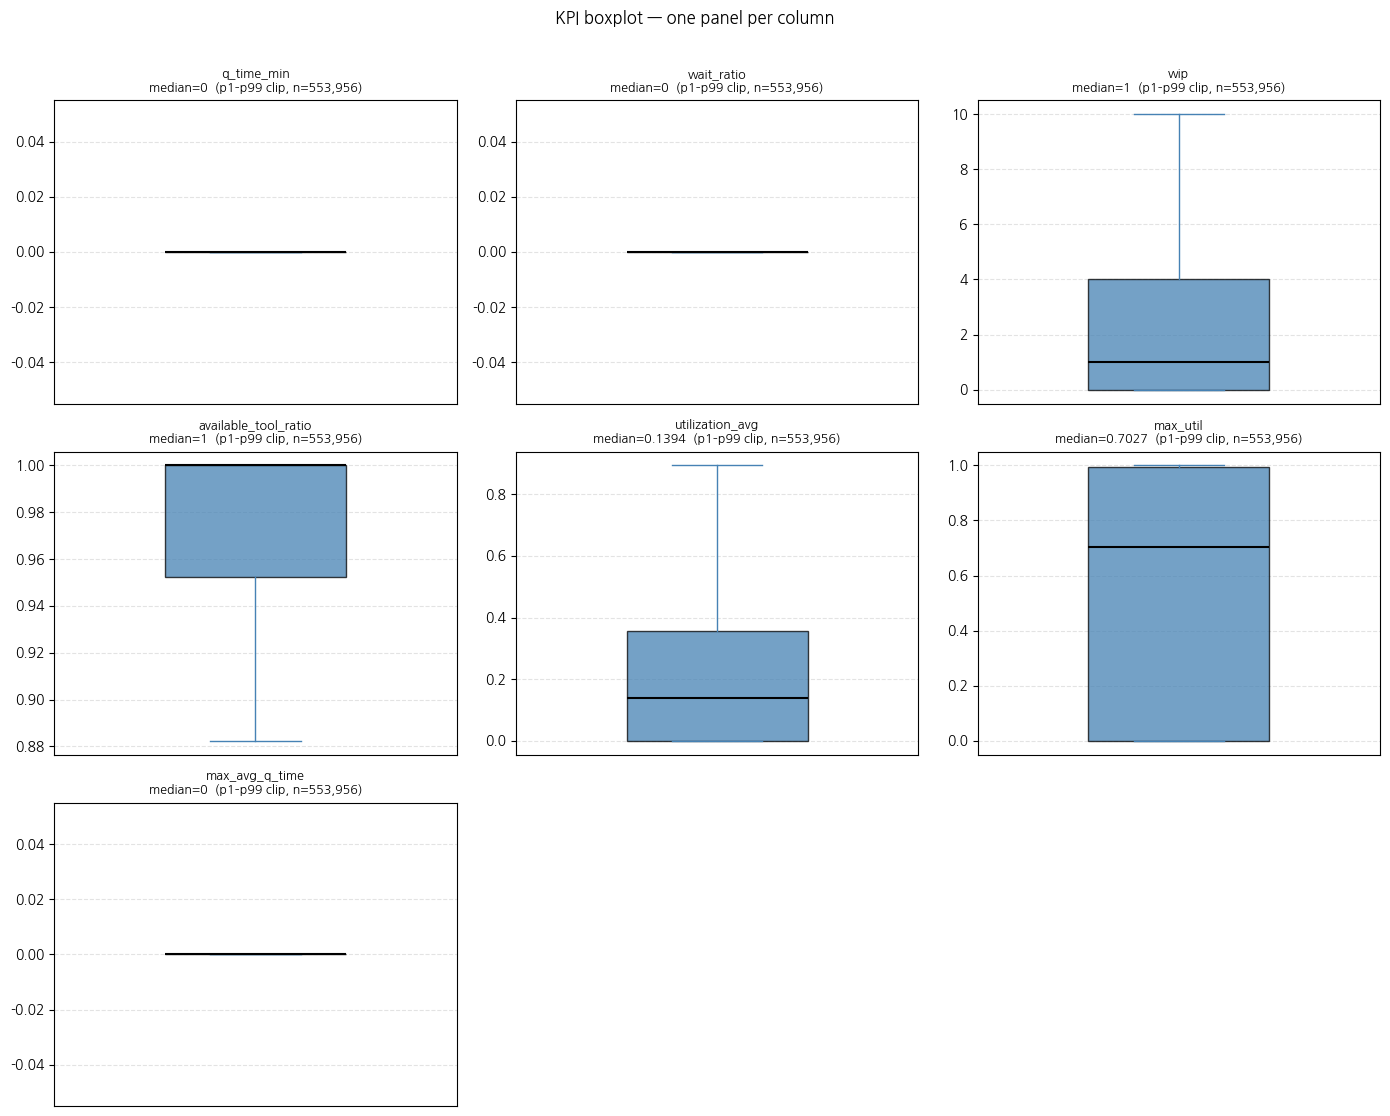

In [12]:
# §5-2) KPI별 boxplot (히스토그램 셀의 X, EDA_COLS 사용)
assert "X" in dir() and "EDA_COLS" in dir(), "먼저 바로 위 EDA 셀(히스토그램)을 실행하세요."

fig_bp, axes_bp = plt.subplots(3, 3, figsize=(14, 11))
axes_bp = axes_bp.ravel()
for ax, col in zip(axes_bp, EDA_COLS):
    s = X[col].dropna()
    if s.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(col)
        continue
    lo, hi = float(s.quantile(0.01)), float(s.quantile(0.99))
    s_clip = s.clip(lo, hi)
    ax.boxplot(
        s_clip,
        vert=True,
        widths=0.45,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
        boxprops={"facecolor": "steelblue", "alpha": 0.75},
        whiskerprops={"color": "steelblue"},
        capprops={"color": "steelblue"},
    )
    ax.set_title(
        f"{col}\nmedian={s.median():.4g}  (p1–p99 clip, n={len(s):,})",
        fontsize=9,
    )
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.35, linestyle="--")
for j in range(len(EDA_COLS), len(axes_bp)):
    axes_bp[j].set_visible(False)
fig_bp.suptitle("KPI boxplot — one panel per column", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 6) REPORT 규칙 + **H=120** lookahead — `y_bottleneck`

- **입력(X):** `wide`의 **t 시점** KPI.
- **라벨(y):** 같은 TG의 **t+120분** KPI에 `REPORT_SIMULATION_KPI.md` §7.2 부등식 적용.
- **임계값:** `wide` 분위수 → `Q_THR`(q_time_min), **`Q_MAX_THR`**(max_avg_q_time), `W_THR` … `U_LO`.
- **누수 주의:** train/valid 분리 시 `THR_REF_DF=train_wide`.

```text
y = 1 if
  (q_time_min >= Q and (wait_ratio >= W or wip >= N))
  or (available_tool_ratio <= A)
  or (max_util >= U_hi and utilization_avg < U_lo)
  or (max_avg_q_time >= Q_MAX and wait_ratio <= W)   # Q 와 별도 임계값
```

`USE_FIXED_THRESHOLDS=True` 이면 문서 가이드 상수를 씁니다.


In [13]:
LOOKAHEAD_MIN = 120.0  # H = 2h (스냅 60분이면 +2 스텝)

from typing import Literal

USE_FIXED_THRESHOLDS = False

# param → (wide 컬럼, upper|lower, 분위 q)
REPORT_THRESHOLD_QUANTILES: dict[str, tuple[str, Literal["upper", "lower"], float]] = {
    "Q": ("q_time_min", "upper", 0.97),
    "Q_MAX": ("max_avg_q_time", "upper", 0.97),
    "W": ("wait_ratio", "upper", 0.97),
    "WIP": ("wip", "upper", 0.97),
    "A": ("available_tool_ratio", "lower", 0.01),
    "U_HI": ("max_util", "upper", 0.75),
    "U_LO": ("utilization_avg", "lower", 0.95),
}

THR_REF_DF: pd.DataFrame | None = None

REPORT_FIXED_THRESHOLDS = {
    "Q": 30.0,
    "Q_MAX": 30.0,
    "W": 1.0,
    "WIP": 3.0,
    "A": 0.5,
    "U_HI": 0.8,
    "U_LO": 0.5,
}


def compute_report_thresholds(
    ref: pd.DataFrame,
    rules: dict[str, tuple[str, Literal["upper", "lower"], float]],
) -> pd.Series:
    out: dict[str, float] = {}
    for param, (col, _tail, q) in rules.items():
        if col not in ref.columns:
            raise KeyError(f"ref 에 컬럼 없음: {col} ({param})")
        if not 0 < q < 1:
            raise ValueError(f"{param}: q 는 (0,1), got {q}")
        s = pd.to_numeric(ref[col], errors="coerce").dropna()
        if s.empty:
            raise ValueError(f"{param}/{col}: 유효 값 없음")
        out[param] = float(s.quantile(q))
    return pd.Series(out)


assert "wide" in dir() and isinstance(wide, pd.DataFrame)

_ref = wide if THR_REF_DF is None else THR_REF_DF

if USE_FIXED_THRESHOLDS:
    report_thr = pd.Series(REPORT_FIXED_THRESHOLDS)
    print("[FIXED] REPORT thresholds")
else:
    report_thr = compute_report_thresholds(_ref, REPORT_THRESHOLD_QUANTILES)
    print(f"[QUANTILE] ref rows={len(_ref):,}")

Q_THR = float(report_thr["Q"])
Q_MAX_THR = float(report_thr["Q_MAX"])
W_THR = float(report_thr["W"])
WIP_THR = float(report_thr["WIP"])
AVAIL_THR = float(report_thr["A"])
U_HI = float(report_thr["U_HI"])
U_LO = float(report_thr["U_LO"])

thr_table = pd.DataFrame({"param": report_thr.index, "threshold": report_thr.values})
if not USE_FIXED_THRESHOLDS:
    thr_table["column"] = [REPORT_THRESHOLD_QUANTILES[p][0] for p in report_thr.index]
    thr_table["tail"] = [REPORT_THRESHOLD_QUANTILES[p][1] for p in report_thr.index]
    thr_table["q"] = [REPORT_THRESHOLD_QUANTILES[p][2] for p in report_thr.index]
display(thr_table.round(6))

print(
    f"Q={Q_THR:.6f}, Q_MAX={Q_MAX_THR:.6f}, W={W_THR:.6f}, WIP={WIP_THR:.6f}, "
    f"A={AVAIL_THR:.6f}, U_HI={U_HI:.6f}, U_LO={U_LO:.6f}"
)

LABEL_KPI_COLS = [
    "q_time_min",
    "wait_ratio",
    "wip",
    "available_tool_ratio",
    "utilization_avg",
    "max_util",
    "max_avg_q_time",
]


def attach_future_labels_tg(
    df: pd.DataFrame,
    horizon: float,
    label_cols: list[str],
) -> pd.DataFrame:
    keys = ["run_id", "snapshot_time", "toolgroup"] if "run_id" in df.columns else ["snapshot_time", "toolgroup"]
    miss = [c for c in label_cols if c not in df.columns]
    if miss:
        raise KeyError(miss)
    future = df[[*keys, *label_cols]].copy()
    future = future.rename(columns={c: f"{c}_future" for c in label_cols})
    future["snapshot_time"] = future["snapshot_time"] - horizon
    return df.merge(future, on=keys, how="inner")


def assign_y_bottleneck_report(
    df: pd.DataFrame,
    *,
    q_thr: float,
    q_max_thr: float,
    w_thr: float,
    wip_thr: float,
    avail_thr: float,
    u_hi: float,
    u_lo: float,
) -> pd.Series:
    """REPORT §7.2 — 부등식은 t+H (*_future)."""
    q = df["q_time_min_future"].fillna(0)
    w = df["wait_ratio_future"].fillna(0)
    wip = df["wip_future"].fillna(0)
    avail = df["available_tool_ratio_future"].fillna(0)
    util_avg = df["utilization_avg_future"].fillna(0)
    max_util = df["max_util_future"].fillna(0)
    max_q = df["max_avg_q_time_future"].fillna(0)

    cond_tg = (q >= q_thr) & ((w >= w_thr) | (wip >= wip_thr))
    cond_avail = avail <= avail_thr
    cond_util = (max_util >= u_hi) & (util_avg < u_lo)
    cond_max_q = (max_q >= q_max_thr) & (w < w_thr)

    return (cond_tg | cond_avail | cond_util | cond_max_q).astype("int8")


n_before = len(wide)
n_tg = wide["toolgroup"].nunique()

wide_train = attach_future_labels_tg(wide, LOOKAHEAD_MIN, LABEL_KPI_COLS)
n_after = len(wide_train)
dropped = n_before - n_after

print(f"wide rows: {n_before:,}")
print(f"after inner merge (need t+{LOOKAHEAD_MIN:.0f}): {n_after:,}  (dropped {dropped:,})")
print(f"n_toolgroups={n_tg} → expected drop ≈ 2 × n_tg = {2 * n_tg}")

wide_train["y_bottleneck"] = assign_y_bottleneck_report(
    wide_train,
    q_thr=Q_THR,
    q_max_thr=Q_MAX_THR,
    w_thr=W_THR,
    wip_thr=WIP_THR,
    avail_thr=AVAIL_THR,
    u_hi=U_HI,
    u_lo=U_LO,
)

pos = wide_train["y_bottleneck"].sum()
print(
    f"y_bottleneck positive: {int(pos):,} / {len(wide_train):,} "
    f"({100 * pos / len(wide_train):.2f}%)"
)


[QUANTILE] ref rows=553,956


,param,threshold,column,tail,q
0,Q,980.954787,q_time_min,upper,0.97
1,Q_MAX,1062.941575,max_avg_q_time,upper,0.97
2,W,4.500000,wait_ratio,upper,0.97
3,WIP,44.000000,wip,upper,0.97
4,A,0.500000,available_tool_ratio,lower,0.01
5,U_HI,0.995463,max_util,upper,0.75
6,U_LO,0.855718,utilization_avg,lower,0.95


Q=980.954787, Q_MAX=1062.941575, W=4.500000, WIP=44.000000, A=0.500000, U_HI=0.995463, U_LO=0.855718
wide rows: 553,956
after inner merge (need t+120): 553,744  (dropped 212)
n_toolgroups=106 → expected drop ≈ 2 × n_tg = 212
y_bottleneck positive: 157,225 / 553,744 (28.39%)


In [14]:
wide_train

kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg,max_avg_q_time,max_util,q_time_min_future,wait_ratio_future,wip_future,available_tool_ratio_future,utilization_avg_future,max_util_future,max_avg_q_time_future,y_bottleneck
0,60.0,DE_BE_11,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
1,60.0,DE_BE_12,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
2,60.0,DE_BE_13,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
3,60.0,DE_BE_48,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
4,60.0,DE_BE_50,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553739,313440.0,WE_FE_47,1.000000,0.000000,0.000000,1.0,0.0,0.409431,0.000000,0.551976,0.000000,0.000000,0.0,1.000000,0.039227,0.235363,0.000000,0
553740,313440.0,WE_FE_8,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.245001,0.320134,0.000000,0
553741,313440.0,WE_FE_83,1.000000,0.000000,0.000000,3.0,0.0,0.568209,0.000000,0.898911,0.000000,0.000000,3.0,1.000000,0.450160,0.687690,0.000000,0
553742,313440.0,WE_FE_84,0.894737,174.520477,0.058824,9.0,0.0,0.532037,174.520477,0.943470,294.520477,0.058824,11.0,0.894737,0.195764,0.836513,294.520477,0


## 7) Feature engineering — KPI **Δ(t − t−120)**

- **입력:** §6 `wide_train` (시각 **t** KPI + `*_future` 라벨용 컬럼).
- **lag:** `DELTA_LAG_MIN = 120` — 60분 스냅이면 **2스텝 전**과 merge (`inner` → run 초반 120분 구간 drop).
- **피처:** `{kpi}_delta_120 = kpi(t) − kpi(t−120)` for `q_time_min`, `wait_ratio`, `wip`, `max_util`, `utilization_avg`.
- **중간 컬럼** `{kpi}_lag120` 은 §8에서 자동 제외 (`EXCLUDE_SUBSTR`).


In [15]:
DELTA_LAG_MIN = 120.0  # LOOKAHEAD_MIN 과 동일 권장

DELTA_KPI_COLS = [
    "q_time_min",
    "wait_ratio",
    "wip",
    "max_util",
    "utilization_avg",
]

DELTA_SUFFIX = "_delta_120"
LAG_SUFFIX = "_lag120"


def attach_past_kpis_tg(
    df: pd.DataFrame,
    lag_min: float,
    kpi_cols: list[str],
    *,
    lag_suffix: str = LAG_SUFFIX,
) -> pd.DataFrame:
    """현재 행 t 에 KPI(t - lag_min) 를 붙임."""
    keys = ["run_id", "snapshot_time", "toolgroup"] if "run_id" in df.columns else ["snapshot_time", "toolgroup"]
    miss = [c for c in kpi_cols if c not in df.columns]
    if miss:
        raise KeyError(miss)
    past = df[[*keys, *kpi_cols]].copy()
    past = past.rename(columns={c: f"{c}{lag_suffix}" for c in kpi_cols})
    past["snapshot_time"] = past["snapshot_time"] + lag_min
    return df.merge(past, on=keys, how="inner")


def add_kpi_deltas(
    df: pd.DataFrame,
    kpi_cols: list[str],
    *,
    lag_suffix: str = LAG_SUFFIX,
    delta_suffix: str = DELTA_SUFFIX,
) -> pd.DataFrame:
    out = df.copy()
    for c in kpi_cols:
        cur = pd.to_numeric(out[c], errors="coerce")
        lag = pd.to_numeric(out[f"{c}{lag_suffix}"], errors="coerce")
        out[f"{c}{delta_suffix}"] = cur - lag
    return out


assert "wide_train" in dir() and isinstance(wide_train, pd.DataFrame)

n_before = len(wide_train)
wide_train = attach_past_kpis_tg(wide_train, DELTA_LAG_MIN, DELTA_KPI_COLS)
wide_train = add_kpi_deltas(wide_train, DELTA_KPI_COLS)
n_after = len(wide_train)

DELTA_FEATURE_COLS = [f"{c}{DELTA_SUFFIX}" for c in DELTA_KPI_COLS]

print(f"wide_train rows: {n_before:,} → {n_after:,}  (need t−{DELTA_LAG_MIN:.0f}min, dropped {n_before - n_after:,})")
print("delta features:", DELTA_FEATURE_COLS)

display(
    wide_train[["snapshot_time", "toolgroup", *DELTA_KPI_COLS, *DELTA_FEATURE_COLS]]
    .head(6)
)


wide_train rows: 553,744 → 553,532  (need t−120min, dropped 212)
delta features: ['q_time_min_delta_120', 'wait_ratio_delta_120', 'wip_delta_120', 'max_util_delta_120', 'utilization_avg_delta_120']


kpi_name,snapshot_time,toolgroup,q_time_min,wait_ratio,wip,max_util,utilization_avg,q_time_min_delta_120,wait_ratio_delta_120,wip_delta_120,max_util_delta_120,utilization_avg_delta_120
0,180.0,DE_BE_11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,180.0,DE_BE_12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,180.0,DE_BE_13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,180.0,DE_BE_48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,180.0,DE_BE_50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,180.0,DE_BE_65,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7-1) TG별 Min-Max scaling (0~1)

- **위치:** §7 `*_delta_120` 생성 **이후**, §8 XGBoost **이전**
- **대상:** level `KPI_COLS` + `DELTA_FEATURE_COLS` (`*_future`, `*_lag120`, `y_bottleneck` 등은 **미변경**)
- **fit:** §8과 동일 **시간 70% train** 구간·**TG별** `min` / `max` → `(x - min_tg) / (max_tg - min_tg)`, `[0, 1]` clip
- **토글:** `USE_TG_MINMAX_SCALE = False` 이면 스킵 (원시 KPI 유지)
- **통계 테이블:** `tg_minmax_stats` (행 = toolgroup × feature)

In [16]:
# §7-1 TG별 min-max (train 시간 구간만으로 fit)

import numpy as np
import pandas as pd
from IPython.display import display

assert "wide_train" in dir() and isinstance(wide_train, pd.DataFrame)
assert "DELTA_FEATURE_COLS" in dir(), "먼저 §7 delta 셀을 실행하세요."
assert "KPI_COLS" in dir(), "먼저 §5 wide/KPI_COLS 셀을 실행하세요."

USE_TG_MINMAX_SCALE = True
TG_MINMAX_TRAIN_FRAC = 0.70  # §8 temporal split 과 동일
TG_MINMAX_EPS = 1e-9
TG_MINMAX_CLIP = True
TG_MINMAX_FILL_CONSTANT = 0.5  # TG 내 분산이 0일 때 (min == max)

TG_MINMAX_SCALE_COLS = list(dict.fromkeys([*KPI_COLS, *DELTA_FEATURE_COLS]))
_missing = [c for c in TG_MINMAX_SCALE_COLS if c not in wide_train.columns]
if _missing:
    raise KeyError(f"wide_train 에 없는 컬럼: {_missing}")


def temporal_train_mask(
    df: pd.DataFrame,
    *,
    train_frac: float = 0.70,
    time_col: str = "snapshot_time",
) -> pd.Series:
    """§8 과 동일: unique snapshot_time 기준 앞 train_frac 구간."""
    times = np.sort(df[time_col].astype(float).unique())
    n_t = len(times)
    i_train_end = int(n_t * train_frac)
    i_train_end = max(1, min(i_train_end, n_t - 2))
    t_train_max = times[i_train_end - 1]
    return df[time_col] <= t_train_max


def fit_tg_minmax_stats(
    df: pd.DataFrame,
    cols: list[str],
    *,
    group_col: str = "toolgroup",
) -> pd.DataFrame:
    """TG × feature 별 min, max (train 행만 넣어 호출)."""
    rows: list[dict] = []
    for tg, g in df.groupby(group_col, sort=False):
        for c in cols:
            s = pd.to_numeric(g[c], errors="coerce")
            vmin = float(s.min()) if s.notna().any() else 0.0
            vmax = float(s.max()) if s.notna().any() else 0.0
            rows.append(
                {
                    group_col: tg,
                    "feature": c,
                    "vmin": vmin,
                    "vmax": vmax,
                    "n_train": int(s.notna().sum()),
                }
            )
    return pd.DataFrame(rows)


def transform_tg_minmax(
    df: pd.DataFrame,
    stats: pd.DataFrame,
    cols: list[str],
    *,
    group_col: str = "toolgroup",
    eps: float = TG_MINMAX_EPS,
    clip: bool = TG_MINMAX_CLIP,
    fill_constant: float = TG_MINMAX_FILL_CONSTANT,
) -> pd.DataFrame:
    out = df.copy()
    vmin_w = stats.pivot(index=group_col, columns="feature", values="vmin")
    vmax_w = stats.pivot(index=group_col, columns="feature", values="vmax")

    for c in cols:
        if c not in vmin_w.columns:
            raise KeyError(f"stats 에 feature 없음: {c}")
        vmin = out[group_col].map(vmin_w[c])
        vmax = out[group_col].map(vmax_w[c])
        x = pd.to_numeric(out[c], errors="coerce")
        denom = (vmax - vmin).clip(lower=eps)
        constant = (vmax - vmin).abs() <= eps
        scaled = (x - vmin) / denom
        scaled = scaled.where(~constant, fill_constant)
        if clip:
            scaled = scaled.clip(0.0, 1.0)
        out[c] = scaled
    return out


if not USE_TG_MINMAX_SCALE:
    print("USE_TG_MINMAX_SCALE=False — wide_train KPI/delta 원시값 유지")
else:
    _train_mask = temporal_train_mask(wide_train, train_frac=TG_MINMAX_TRAIN_FRAC)
    _df_fit = wide_train.loc[_train_mask]
    tg_minmax_stats = fit_tg_minmax_stats(_df_fit, TG_MINMAX_SCALE_COLS)

    _n_tg = wide_train["toolgroup"].nunique()
    _n_const = int(
        ((tg_minmax_stats["vmax"] - tg_minmax_stats["vmin"]).abs() <= TG_MINMAX_EPS).sum()
    )
    print(
        f"TG min-max fit: train rows={_train_mask.sum():,} / {len(wide_train):,} "
        f"(time_frac={TG_MINMAX_TRAIN_FRAC})"
    )
    print(f"  toolgroups={_n_tg}  scaled cols={len(TG_MINMAX_SCALE_COLS)}  constant pairs={_n_const}")

    wide_train = transform_tg_minmax(wide_train, tg_minmax_stats, TG_MINMAX_SCALE_COLS)

    # display(tg_minmax_stats.head(12))
    # display(
    #     wide_train[
    #         ["snapshot_time", "toolgroup", *TG_MINMAX_SCALE_COLS[:4], *DELTA_FEATURE_COLS[:2]]
    #     ].head(6)
    # )

TG min-max fit: train rows=387,430 / 553,532 (time_frac=0.7)
  toolgroups=106  scaled cols=13  constant pairs=207


In [17]:
wide_train

kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg,max_avg_q_time,max_util,...,q_time_min_lag120,wait_ratio_lag120,wip_lag120,max_util_lag120,utilization_avg_lag120,q_time_min_delta_120,wait_ratio_delta_120,wip_delta_120,max_util_delta_120,utilization_avg_delta_120
0,180.0,DE_BE_11,1.000000,0.500000,0.500000,0.000000,0.5,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.500000,0.500000,0.500000,0.500000,0.468859
1,180.0,DE_BE_12,1.000000,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.669224,0.500000,0.450000,0.500000,0.492305
2,180.0,DE_BE_13,1.000000,0.500000,0.500000,0.000000,0.5,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.500000,0.500000,0.500000,0.500000,0.466719
3,180.0,DE_BE_48,1.000000,0.500000,0.500000,0.000000,0.5,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.500000,0.500000,0.428571,0.500000,0.471993
4,180.0,DE_BE_50,1.000000,0.500000,0.500000,0.000000,0.5,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.500000,0.500000,0.454545,0.500000,0.542120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553527,313440.0,WE_FE_47,1.000000,0.000000,0.000000,0.111111,0.5,0.455819,0.000000,0.552255,...,16.880558,0.166667,6.0,0.860190,0.571115,0.644963,0.333333,0.187500,0.346978,0.392832
553528,313440.0,WE_FE_8,1.000000,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.0,0.947909,0.707442,0.707828,0.515152,0.388889,0.023661,0.142158
553529,313440.0,WE_FE_83,1.000000,0.000000,0.000000,0.214286,0.5,0.580822,0.000000,0.900313,...,0.000000,0.000000,4.0,0.585380,0.327677,0.566561,0.500000,0.416667,0.672373,0.640239
553530,313440.0,WE_FE_84,0.333333,0.319321,0.132353,0.346154,0.5,0.592887,0.308274,0.943665,...,54.520477,0.058824,10.0,0.987917,0.566340,0.814969,0.486486,0.511628,0.482569,0.475198


## 8) XGBoost — 학습 / 검증 / 평가 **70 : 15 : 15**

- **피처:** 시각 **t** 수치 KPI + (§7) `{kpi}_delta_120` — §7-1에서 TG별 min-max 적용 시 **0~1 스케일**. `*_future`·`*_lag120`·`y_bottleneck`·`snapshot_time` 제외.
- **토글:** `USE_LEVEL_FEATURES` / `USE_DELTA_FEATURES` — delta만 끄거나 level만 쓸 수 있음.
- **추가 제외:** `EXCLUDE_NAMES` · `EXCLUDE_SUBSTR` · `EXCLUDE_FEATURE_COLS`.
- **TG ID:** `USE_TOOLGROUP_ENC=True` 일 때만 `toolgroup_enc`를 `FEATURE_COLS`에 추가 (`EXCLUDE_NAMES`로는 제거 불가).


In [25]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("pip install xgboost") from e

assert "wide_train" in dir() and "y_bottleneck" in wide_train.columns, (
    "먼저 섹션 6·7까지 실행해 wide_train, y_bottleneck, DELTA_FEATURE_COLS 를 만드세요."
)
assert "DELTA_FEATURE_COLS" in dir(), "먼저 §7 delta 셀을 실행하세요."

RANDOM_STATE = 42
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

# --- feature toggles (실험 시 여기만 변경) ---
USE_LEVEL_FEATURES = True
USE_DELTA_FEATURES = True
USE_TOOLGROUP_ENC = False  # True 시 FEATURE_COLS에 toolgroup_enc 추가 (§7-1 scaling 후 False 권장)

# lag / future / label 은 피처에서 제외
EXCLUDE_SUBSTR = ("_future", "_lag120")
EXCLUDE_NAMES = {
    "max_avg_q_time",
    "setup_ratio_avg",
    "y_bottleneck",
    "run_id",
    "snapshot_time",
}
# toolgroup_enc 는 wide_train 컬럼이 아님 → EXCLUDE_NAMES 무효. USE_TOOLGROUP_ENC 로 제어.
# 개별 컬럼 강제 제외 (예: {"q_time_min_delta_120"})
EXCLUDE_FEATURE_COLS: set[str] = set()


def is_delta_feature(col: str, delta_suffix: str = "_delta_120") -> bool:
    return col.endswith(delta_suffix)


def build_numeric_feature_cols(
    df: pd.DataFrame,
    *,
    use_level: bool = True,
    use_delta: bool = True,
    exclude_names: set[str] | None = None,
    exclude_substr: tuple[str, ...] = (),
    exclude_cols: set[str] | None = None,
    delta_cols: list[str] | None = None,
) -> list[str]:
    exclude_names = exclude_names or set()
    exclude_cols = exclude_cols or set()
    delta_set = set(delta_cols or [])

    candidates = [
        c
        for c in df.columns
        if c not in exclude_names
        and c != "toolgroup"
        and c not in exclude_cols
        and not any(s in c for s in exclude_substr)
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    level_cols = [c for c in candidates if c not in delta_set and not is_delta_feature(c)]
    delta_only = [c for c in candidates if c in delta_set or is_delta_feature(c)]

    out: list[str] = []
    if use_level:
        out.extend(level_cols)
    if use_delta:
        out.extend(delta_only)
    return out


num_cols = build_numeric_feature_cols(
    wide_train,
    use_level=USE_LEVEL_FEATURES,
    use_delta=USE_DELTA_FEATURES,
    exclude_names=EXCLUDE_NAMES,
    exclude_substr=EXCLUDE_SUBSTR,
    exclude_cols=EXCLUDE_FEATURE_COLS,
    delta_cols=DELTA_FEATURE_COLS,
)

df_ml = wide_train[["snapshot_time", "toolgroup", *num_cols, "y_bottleneck"]].copy()
df_ml[num_cols] = df_ml[num_cols].apply(pd.to_numeric, errors="coerce")

le_tg = None
if USE_TOOLGROUP_ENC:
    le_tg = LabelEncoder()
    df_ml["toolgroup_enc"] = le_tg.fit_transform(df_ml["toolgroup"].astype(str))
    FEATURE_COLS = num_cols + ["toolgroup_enc"]
else:
    FEATURE_COLS = list(num_cols)

print(
    "features:",
    f"level={USE_LEVEL_FEATURES}",
    f"delta={USE_DELTA_FEATURES}",
    f"toolgroup_enc={USE_TOOLGROUP_ENC}",
    f"n={len(FEATURE_COLS)}",
)
print("  FEATURE_COLS:", FEATURE_COLS)
print("  level cols:", [c for c in num_cols if not is_delta_feature(c)])
print("  delta cols:", [c for c in num_cols if is_delta_feature(c)])


def temporal_split_by_snapshot_time(
    df: pd.DataFrame,
    *,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split by unique snapshot_time (ascending). All TG rows at time t stay in one fold."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    times = np.sort(df["snapshot_time"].astype(float).unique())
    n_t = len(times)
    i_train_end = int(n_t * train_frac)
    i_val_end = int(n_t * (train_frac + val_frac))
    i_train_end = max(1, min(i_train_end, n_t - 2))
    i_val_end = max(i_train_end + 1, min(i_val_end, n_t - 1))

    t_train_max = times[i_train_end - 1]
    t_val_max = times[i_val_end - 1]

    train = df[df["snapshot_time"] <= t_train_max]
    val = df[(df["snapshot_time"] > t_train_max) & (df["snapshot_time"] <= t_val_max)]
    test = df[df["snapshot_time"] > t_val_max]
    return train, val, test


df_train, df_val, df_test = temporal_split_by_snapshot_time(
    df_ml, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC
)

X_train = df_train[FEATURE_COLS].fillna(0.0)
X_val = df_val[FEATURE_COLS].fillna(0.0)
X_test = df_test[FEATURE_COLS].fillna(0.0)
y_train = df_train["y_bottleneck"].astype(int).values
y_val = df_val["y_bottleneck"].astype(int).values
y_test = df_test["y_bottleneck"].astype(int).values

n = len(df_ml)
print("n=", n, " n_features=", len(FEATURE_COLS), " pos_rate=", round(df_ml["y_bottleneck"].mean() * 100, 2), "%")
print(
    "sizes train/val/test:",
    len(X_train),
    len(X_val),
    len(X_test),
    " fractions:",
    round(len(X_train) / n, 4),
    round(len(X_val) / n, 4),
    round(len(X_test) / n, 4),
)
for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
    tmin, tmax = part["snapshot_time"].min(), part["snapshot_time"].max()
    print(f"  {name} snapshot_time: {tmin:.0f} → {tmax:.0f}  pos_rate={part['y_bottleneck'].mean()*100:.2f}%")

scale_pos_weight = float((y_train == 0).sum() / max(1, (y_train == 1).sum()))

model = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.06,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)


features: level=True delta=True toolgroup_enc=False n=11
  FEATURE_COLS: ['available_tool_ratio', 'q_time_min', 'wait_ratio', 'wip', 'utilization_avg', 'max_util', 'q_time_min_delta_120', 'wait_ratio_delta_120', 'wip_delta_120', 'max_util_delta_120', 'utilization_avg_delta_120']
  level cols: ['available_tool_ratio', 'q_time_min', 'wait_ratio', 'wip', 'utilization_avg', 'max_util']
  delta cols: ['q_time_min_delta_120', 'wait_ratio_delta_120', 'wip_delta_120', 'max_util_delta_120', 'utilization_avg_delta_120']
n= 553532  n_features= 11  pos_rate= 28.4 %
sizes train/val/test: 387430 82998 83104  fractions: 0.6999 0.1499 0.1501
  train snapshot_time: 180 → 219420  pos_rate=27.53%
  val snapshot_time: 219480 → 266400  pos_rate=30.51%
  test snapshot_time: 266460 → 313440  pos_rate=30.36%
[0]	validation_0-logloss:0.66069
[50]	validation_0-logloss:0.32186
[100]	validation_0-logloss:0.30520
[150]	validation_0-logloss:0.29978
[200]	validation_0-logloss:0.29700
[250]	validation_0-logloss:0.295

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.85
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [26]:
# §8-1 validation threshold sweep (참고) + 운영 임계값
ALARM_PROBA_THRESHOLD = 0.7  # §8 test 리포트 / §9 SHAP 공통

PROBA_THRESHOLDS = np.arange(0.05, 0.96, 0.05)  # 또는 0.01 간격

val_proba = model.predict_proba(X_val)[:, 1]

rows = []
for t in PROBA_THRESHOLDS:
    pred = (val_proba >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_val, pred, average="binary", zero_division=0)
    rows.append({"threshold": t, "precision": p, "recall": r, "f1": f1})

thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(thr_df.head(10))

pred_alarm = (val_proba >= ALARM_PROBA_THRESHOLD).astype(int)
p, r, f1, _ = precision_recall_fscore_support(
    y_val, pred_alarm, average="binary", zero_division=0
)
print(
    f"validation @ ALARM_PROBA_THRESHOLD={ALARM_PROBA_THRESHOLD:.2f}: "
    f"precision={p:.4f} recall={r:.4f} f1={f1:.4f}"
)

,threshold,precision,recall,f1
11,0.60,0.785232,0.845826,0.814404
10,0.55,0.770750,0.862886,0.814220
12,0.65,0.800314,0.825409,0.812668
9,0.50,0.755254,0.878406,0.812188
13,0.70,0.816323,0.799463,0.807805
8,0.45,0.735931,0.892899,0.806852
7,0.40,0.721293,0.905932,0.803137
14,0.75,0.838192,0.761828,0.798188
6,0.35,0.703805,0.917542,0.796585
5,0.30,0.681842,0.928007,0.786104


validation @ ALARM_PROBA_THRESHOLD=0.70: precision=0.8163 recall=0.7995 f1=0.8078


In [27]:
assert "ALARM_PROBA_THRESHOLD" in dir(), "먼저 §8-1 임계값 셀을 실행하세요."


def _report(split_name: str, Xs, ys, *, threshold: float = ALARM_PROBA_THRESHOLD) -> None:
    proba = model.predict_proba(Xs)[:, 1]
    pred = (proba >= threshold).astype(int)
    print("\n===", split_name, f"(proba >= {threshold:.2f}) ===")
    print("accuracy:", round(accuracy_score(ys, pred), 4))
    if len(set(ys)) > 1:
        print("roc_auc:", round(roc_auc_score(ys, proba), 4))
    print("confusion_matrix [ [TN FP] [FN TP] ]:")
    print(confusion_matrix(ys, pred))
    print(classification_report(ys, pred, digits=4))


#_report("validation", X_val, y_val)
_report("test (hold-out)", X_test, y_test)

imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
display(imp.head(20).to_frame("importance"))


=== test (hold-out) (proba >= 0.70) ===
accuracy: 0.8831
roc_auc: 0.9452
confusion_matrix [ [TN FP] [FN TP] ]:
[[53299  4575]
 [ 5143 20087]]
              precision    recall  f1-score   support

           0     0.9120    0.9209    0.9165     57874
           1     0.8145    0.7962    0.8052     25230

    accuracy                         0.8831     83104
   macro avg     0.8632    0.8586    0.8608     83104
weighted avg     0.8824    0.8831    0.8827     83104



,importance
max_util,0.336329
wip,0.140069
q_time_min,0.104745
q_time_min_delta_120,0.083532
available_tool_ratio,0.070480
wait_ratio_delta_120,0.069949
wait_ratio,0.063862
max_util_delta_120,0.046246
utilization_avg,0.038755
wip_delta_120,0.025162


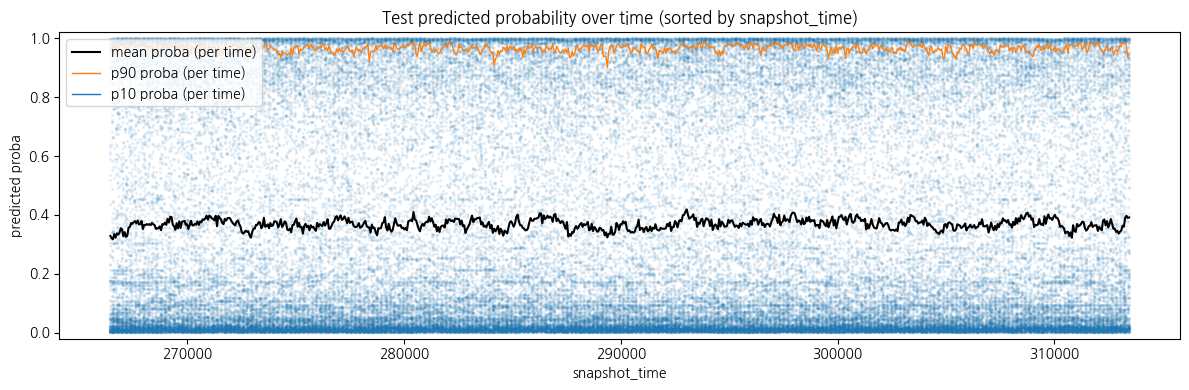

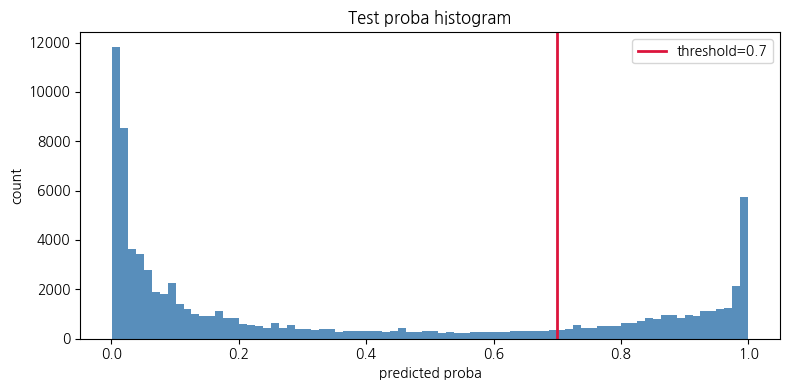

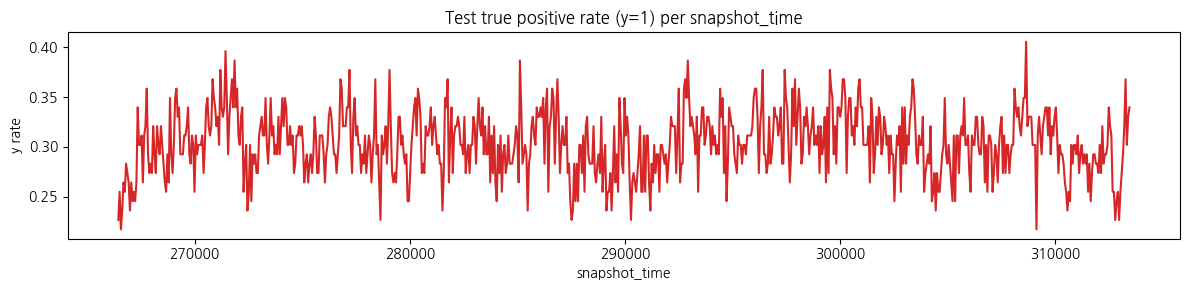

alarms per time (first 10):
snapshot_time
266460.0    27
266520.0    27
266580.0    26
266640.0    30
266700.0    21
266760.0    29
266820.0    29
266880.0    29
266940.0    29
267000.0    30
Name: alarm, dtype: int64
mean alarms per time: 31.456632653061224


In [28]:
# (추가) Test 구간에서 시간 순서로 예측확률 분포 확인
# - df_test에는 snapshot_time, toolgroup, y_bottleneck, feature들이 포함되어 있어야 함 (sec8 셀 실행 후)

import matplotlib.pyplot as plt

assert "df_test" in dir() and "X_test" in dir() and "y_test" in dir(), "먼저 §8 셀을 실행하세요."

proba_test = model.predict_proba(X_test)[:, 1]
plot_df = df_test[["snapshot_time", "toolgroup", "y_bottleneck"]].copy()
plot_df["proba"] = proba_test
plot_df = plot_df.sort_values(["snapshot_time", "toolgroup"]).reset_index(drop=True)

# 1) 시간축 scatter + time별 요약선
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(plot_df["snapshot_time"], plot_df["proba"], s=2, alpha=0.08)

by_t = plot_df.groupby("snapshot_time", as_index=False).agg(
    proba_mean=("proba", "mean"),
    proba_p90=("proba", lambda s: s.quantile(0.90)),
    proba_p10=("proba", lambda s: s.quantile(0.10)),
    y_rate=("y_bottleneck", "mean"),
)
ax.plot(by_t["snapshot_time"], by_t["proba_mean"], color="black", lw=1.5, label="mean proba (per time)")
ax.plot(by_t["snapshot_time"], by_t["proba_p90"], color="tab:orange", lw=1.0, label="p90 proba (per time)")
ax.plot(by_t["snapshot_time"], by_t["proba_p10"], color="tab:blue", lw=1.0, label="p10 proba (per time)")
ax.set_title("Test predicted probability over time (sorted by snapshot_time)")
ax.set_xlabel("snapshot_time")
ax.set_ylabel("predicted proba")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 2) 분포(히스토그램) + 임계값 표시
assert "ALARM_PROBA_THRESHOLD" in dir(), "먼저 §8-1 임계값 셀을 실행하세요."
THR = float(ALARM_PROBA_THRESHOLD)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(plot_df["proba"], bins=80, alpha=0.9, color="steelblue", edgecolor="none")
ax2.axvline(THR, color="crimson", lw=2, label=f"threshold={THR}")
ax2.set_title("Test proba histogram")
ax2.set_xlabel("predicted proba")
ax2.set_ylabel("count")
ax2.legend()
plt.tight_layout()
plt.show()

# 3) 시간별 true 양성률(y)과 proba 평균 비교
fig3, ax3 = plt.subplots(figsize=(12, 3))
ax3.plot(by_t["snapshot_time"], by_t["y_rate"], color="tab:red", lw=1.5)
ax3.set_title("Test true positive rate (y=1) per snapshot_time")
ax3.set_xlabel("snapshot_time")
ax3.set_ylabel("y rate")
plt.tight_layout()
plt.show()

# 4) 시간별 알람 개수(=민감도) 확인
alarm_by_t = plot_df.assign(alarm=(plot_df["proba"] >= THR).astype(int)).groupby("snapshot_time")["alarm"].sum()
print("alarms per time (first 10):")
print(alarm_by_t.head(10))
print("mean alarms per time:", float(alarm_by_t.mean()))


## 9) SHAP — 병목 예측 근거 (처음 10건)

§8에서 학습한 `XGBClassifier`에 대해 **TreeExplainer**로 행(row) 단위 기여도를 계산합니다.

- **대상:** test 구간에서 `proba ≥ ALARM_PROBA_THRESHOLD`(§8-1, 기본 0.7) 인 예측 중, `snapshot_time`·`toolgroup` 순 **앞 10건**
- **출력:** 건별 Top-K SHAP 피처, REPORT 4축 매핑 한글 요약, 막대 차트
- **선행:** §8 학습 셀 + §8-1 (`ALARM_PROBA_THRESHOLD`) 실행

`shap` 미설치 시: `pip install shap` (FAB_BEAR simulation venv)

alarm threshold (proba): 0.70
SHAP 대상: 30 rows (test, y_pred=1, time-ordered first 30)


kpi_name,snapshot_time,toolgroup,proba,y_bottleneck,y_pred
470437,266460.0,DE_FE_1,0.825041,1,1
470438,266460.0,DE_FE_51,0.947571,0,1
470443,266460.0,DE_FE_59,0.803827,1,1
470445,266460.0,DE_FE_70,0.777870,0,1
470446,266460.0,DE_FE_71,0.994451,1,1
470448,266460.0,DE_FE_86,0.995918,1,1
470449,266460.0,DefMEt_FE_118,0.998875,1,1
470451,266460.0,DefMet_BE_42,0.953158,1,1
470453,266460.0,DefMet_FE_106,0.986115,1,1
470454,266460.0,DefMet_FE_34,0.863274,0,1


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.



--- [1/30] t=266460 min | TG=DE_FE_1 | proba=0.825 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.148771,28.4,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.772884,1.066112,26.3,병목 쪽으로 기여(+)
2,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.547008,13.5,병목 쪽으로 기여(+)
3,utilization_avg,가동,TG 평균 가동률,0.127700,0.476529,11.8,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.953364,-0.298224,7.4,병목 아님 쪽으로 기여(-)
5,wip,혼잡,WIP(작업량),0.100000,0.232031,5.7,병목 쪽으로 기여(+)



--- [2/30] t=266460 min | TG=DE_FE_51 | proba=0.948 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.989903,38.0,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.384615,1.430670,27.3,병목 쪽으로 기여(+)
2,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.760941,0.647672,12.4,병목 쪽으로 기여(+)
3,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.466667,0.592924,11.3,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.198585,3.8,병목 쪽으로 기여(+)
5,utilization_avg,가동,TG 평균 가동률,0.468144,-0.149540,2.9,병목 아님 쪽으로 기여(-)



--- [3/30] t=266460 min | TG=DE_FE_59 | proba=0.804 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.832455,1.091561,25.9,병목 쪽으로 기여(+)
1,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.672468,16.0,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.200000,0.647156,15.4,병목 쪽으로 기여(+)
3,utilization_avg,가동,TG 평균 가동률,0.124153,0.521074,12.4,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.346436,0.454824,10.8,병목 쪽으로 기여(+)
5,wip_delta_120,혼잡,WIP 2h 변화,0.428571,0.296548,7.0,병목 쪽으로 기여(+)



--- [4/30] t=266460 min | TG=DE_FE_70 | proba=0.778 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.685325,36.7,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.400000,1.417433,30.9,병목 쪽으로 기여(+)
2,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.402856,8.8,병목 쪽으로 기여(+)
3,max_util_delta_120,가동,max_util 2h 변화,0.550628,-0.374542,8.2,병목 아님 쪽으로 기여(-)
4,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.773402,0.197857,4.3,병목 쪽으로 기여(+)
5,utilization_avg,가동,TG 평균 가동률,0.342055,-0.174073,3.8,병목 아님 쪽으로 기여(-)



--- [5/30] t=266460 min | TG=DE_FE_71 | proba=0.994 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.772879,38.8,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.676166,1.803011,25.2,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.363636,1.309570,18.3,병목 쪽으로 기여(+)
3,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.493743,6.9,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.396372,5.5,병목 쪽으로 기여(+)
5,wip_delta_120,혼잡,WIP 2h 변화,0.368421,0.125600,1.8,병목 쪽으로 기여(+)



--- [6/30] t=266460 min | TG=DE_FE_86 | proba=0.996 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.912051,40.2,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.706978,1.438942,19.8,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.325000,1.404688,19.4,병목 쪽으로 기여(+)
3,available_tool_ratio,가용,가용 설비 비율,0.888889,0.589088,8.1,병목 쪽으로 기여(+)
4,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.459783,6.3,병목 쪽으로 기여(+)
5,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.333083,4.6,병목 쪽으로 기여(+)



--- [7/30] t=266460 min | TG=DefMEt_FE_118 | proba=0.999 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,q_time_min,혼잡,대기시간(분),1.000000,2.922675,33.7,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),1.000000,1.748004,20.1,병목 쪽으로 기여(+)
2,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.503208,1.107513,12.8,병목 쪽으로 기여(+)
3,max_util,가동,설비 최대 가동률(hot-spot),0.996901,0.959463,11.0,병목 쪽으로 기여(+)
4,wait_ratio,혼잡,대기 비율,0.655364,0.954150,11.0,병목 쪽으로 기여(+)
5,utilization_avg,가동,TG 평균 가동률,0.994693,0.335462,3.9,병목 쪽으로 기여(+)



--- [8/30] t=266460 min | TG=DefMet_BE_42 | proba=0.953 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,available_tool_ratio,가용,가용 설비 비율,0.000000,1.877320,35.5,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),1.000000,1.683316,31.8,병목 쪽으로 기여(+)
2,utilization_avg,가동,TG 평균 가동률,0.000000,0.458119,8.7,병목 쪽으로 기여(+)
3,q_time_min,혼잡,대기시간(분),1.000000,0.273043,5.2,병목 쪽으로 기여(+)
4,max_util,가동,설비 최대 가동률(hot-spot),0.000000,-0.266331,5.0,병목 아님 쪽으로 기여(-)
5,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.501318,0.230078,4.4,병목 쪽으로 기여(+)



--- [9/30] t=266460 min | TG=DefMet_FE_106 | proba=0.986 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,available_tool_ratio,가용,가용 설비 비율,0.000000,3.467014,50.3,병목 쪽으로 기여(+)
1,utilization_avg,가동,TG 평균 가동률,0.000000,1.015367,14.7,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.052632,0.868818,12.6,병목 쪽으로 기여(+)
3,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.828908,0.613032,8.9,병목 쪽으로 기여(+)
4,max_util,가동,설비 최대 가동률(hot-spot),0.000000,-0.351677,5.1,병목 아님 쪽으로 기여(-)
5,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.500000,0.230605,3.3,병목 쪽으로 기여(+)



--- [10/30] t=266460 min | TG=DefMet_FE_34 | proba=0.863 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,q_time_min,혼잡,대기시간(분),0.536166,2.661312,38.9,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.638298,1.620718,23.7,병목 쪽으로 기여(+)
2,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.691176,-0.666310,9.7,병목 아님 쪽으로 기여(-)
3,utilization_avg,가동,TG 평균 가동률,0.994815,-0.646280,9.5,병목 아님 쪽으로 기여(-)
4,max_util,가동,설비 최대 가동률(hot-spot),0.995096,0.449776,6.6,병목 쪽으로 기여(+)
5,wait_ratio,혼잡,대기 비율,0.318182,0.402035,5.9,병목 쪽으로 기여(+)



--- [11/30] t=266460 min | TG=Delay_32 | proba=0.973 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.158507,39.5,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.439394,1.479922,27.1,병목 쪽으로 기여(+)
2,available_tool_ratio,가용,가용 설비 비율,0.500000,0.874234,16.0,병목 쪽으로 기여(+)
3,q_time_min,혼잡,대기시간(분),0.500000,0.400986,7.3,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.282302,5.2,병목 쪽으로 기여(+)
5,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.087865,1.6,병목 쪽으로 기여(+)



--- [12/30] t=266460 min | TG=Diffusion_FE_100 | proba=0.983 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.927515,31.4,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.750000,1.789483,29.2,병목 쪽으로 기여(+)
2,available_tool_ratio,가용,가용 설비 비율,0.500000,1.041336,17.0,병목 쪽으로 기여(+)
3,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.712948,0.489873,8.0,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.298497,4.9,병목 쪽으로 기여(+)
5,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.212685,3.5,병목 쪽으로 기여(+)



--- [13/30] t=266460 min | TG=Diffusion_FE_101 | proba=0.885 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.691595,35.4,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.523249,1.073515,22.5,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.250000,0.975796,20.4,병목 쪽으로 기여(+)
3,utilization_avg,가동,TG 평균 가동률,0.149208,0.286164,6.0,병목 쪽으로 기여(+)
4,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.533333,0.253529,5.3,병목 쪽으로 기여(+)
5,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.455157,-0.242813,5.1,병목 아님 쪽으로 기여(-)



--- [14/30] t=266460 min | TG=Diffusion_FE_120 | proba=0.997 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.562157,34.0,병목 쪽으로 기여(+)
1,max_util_delta_120,가동,max_util 2h 변화,0.148159,1.626869,21.6,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.375000,1.437755,19.1,병목 쪽으로 기여(+)
3,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.515937,1.181098,15.7,병목 쪽으로 기여(+)
4,available_tool_ratio,가용,가용 설비 비율,0.666667,0.265782,3.5,병목 쪽으로 기여(+)
5,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.483871,0.191548,2.5,병목 쪽으로 기여(+)



--- [15/30] t=266460 min | TG=Diffusion_FE_125 | proba=0.943 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.423085,30.8,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.333333,1.129855,24.5,병목 쪽으로 기여(+)
2,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.761374,0.858085,18.6,병목 쪽으로 기여(+)
3,available_tool_ratio,가용,가용 설비 비율,0.500000,0.677648,14.7,병목 쪽으로 기여(+)
4,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.400000,0.396033,8.6,병목 쪽으로 기여(+)
5,utilization_avg,가동,TG 평균 가동률,0.365569,0.058869,1.3,병목 쪽으로 기여(+)



--- [16/30] t=266460 min | TG=Diffusion_FE_127 | proba=0.997 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.470452,33.0,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.454545,1.788495,23.9,병목 쪽으로 기여(+)
2,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.501930,1.590274,21.3,병목 쪽으로 기여(+)
3,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.466667,0.574255,7.7,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.393072,5.3,병목 쪽으로 기여(+)
5,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.679038,0.379709,5.1,병목 쪽으로 기여(+)



--- [17/30] t=266460 min | TG=Diffusion_FE_44 | proba=0.993 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.002258,29.5,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.588239,1.446171,21.3,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.416667,1.073383,15.8,병목 쪽으로 기여(+)
3,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.622245,0.759473,11.2,병목 쪽으로 기여(+)
4,utilization_avg,가동,TG 평균 가동률,0.171074,0.458361,6.8,병목 쪽으로 기여(+)
5,available_tool_ratio,가용,가용 설비 비율,0.333333,0.388460,5.7,병목 쪽으로 기여(+)



--- [18/30] t=266460 min | TG=Diffusion_FE_94 | proba=0.952 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.734103,29.7,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.250000,0.927069,15.9,병목 쪽으로 기여(+)
2,utilization_avg,가동,TG 평균 가동률,0.142857,0.774001,13.3,병목 쪽으로 기여(+)
3,q_time_min,혼잡,대기시간(분),0.500000,0.591403,10.1,병목 쪽으로 기여(+)
4,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.586760,0.570936,9.8,병목 쪽으로 기여(+)
5,max_util_delta_120,가동,max_util 2h 변화,0.871775,-0.555283,9.5,병목 아님 쪽으로 기여(-)



--- [19/30] t=266460 min | TG=LithoTrack_FE_115 | proba=0.899 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.823265,43.3,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.409091,1.016474,24.1,병목 쪽으로 기여(+)
2,available_tool_ratio,가용,가용 설비 비율,0.250000,0.539517,12.8,병목 쪽으로 기여(+)
3,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.500000,0.186084,4.4,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.184778,4.4,병목 쪽으로 기여(+)
5,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.167597,4.0,병목 쪽으로 기여(+)



--- [20/30] t=266460 min | TG=LithoTrack_FE_95 | proba=0.821 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),0.998047,1.289647,32.6,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.333333,0.833386,21.1,병목 쪽으로 기여(+)
2,q_time_min,혼잡,대기시간(분),0.500000,0.704362,17.8,병목 쪽으로 기여(+)
3,max_util_delta_120,가동,max_util 2h 변화,0.510086,-0.271105,6.9,병목 아님 쪽으로 기여(-)
4,wait_ratio,혼잡,대기 비율,0.500000,0.222727,5.6,병목 쪽으로 기여(+)
5,wip_delta_120,혼잡,WIP 2h 변화,0.394737,0.195073,4.9,병목 쪽으로 기여(+)



--- [21/30] t=266460 min | TG=LithoTrack_FE_96 | proba=0.901 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,available_tool_ratio,가용,가용 설비 비율,0.500000,1.988636,38.2,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.752877,0.803081,15.4,병목 쪽으로 기여(+)
2,utilization_avg,가동,TG 평균 가동률,0.000000,0.670671,12.9,병목 쪽으로 기여(+)
3,wip,혼잡,WIP(작업량),0.090909,0.533624,10.3,병목 쪽으로 기여(+)
4,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.636364,0.533427,10.3,병목 쪽으로 기여(+)
5,max_util,가동,설비 최대 가동률(hot-spot),0.000000,-0.415945,8.0,병목 아님 쪽으로 기여(-)



--- [22/30] t=266460 min | TG=Litho_BE_110 | proba=0.817 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,1.920675,50.7,병목 쪽으로 기여(+)
1,available_tool_ratio,가용,가용 설비 비율,0.500000,0.666391,17.6,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.428571,0.583561,15.4,병목 쪽으로 기여(+)
3,utilization_avg_delta_120,기타,utilization_avg_delta_120,0.415986,-0.146070,3.9,병목 아님 쪽으로 기여(-)
4,q_time_min,혼잡,대기시간(분),0.500000,0.115028,3.0,병목 쪽으로 기여(+)
5,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.106091,2.8,병목 쪽으로 기여(+)



--- [23/30] t=266460 min | TG=Litho_BE_99 | proba=0.979 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,q_time_min,혼잡,대기시간(분),0.767033,2.426822,38.6,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.250000,1.499981,23.9,병목 쪽으로 기여(+)
2,utilization_avg,가동,TG 평균 가동률,0.000000,0.667929,10.6,병목 쪽으로 기여(+)
3,available_tool_ratio,가용,가용 설비 비율,0.666667,0.612421,9.7,병목 쪽으로 기여(+)
4,max_util,가동,설비 최대 가동률(hot-spot),0.000000,-0.338983,5.4,병목 아님 쪽으로 기여(-)
5,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.666667,0.237992,3.8,병목 쪽으로 기여(+)



--- [24/30] t=266460 min | TG=Litho_FE_111 | proba=0.856 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.038317,43.6,병목 쪽으로 기여(+)
1,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.583738,0.860905,18.4,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.281250,0.802731,17.2,병목 쪽으로 기여(+)
3,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.336590,7.2,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.493832,-0.290401,6.2,병목 아님 쪽으로 기여(-)
5,wip_delta_120,혼잡,WIP 2h 변화,0.571429,-0.132738,2.8,병목 아님 쪽으로 기여(-)



--- [25/30] t=266460 min | TG=Litho_FE_92 | proba=0.894 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,available_tool_ratio,가용,가용 설비 비율,0.272727,1.252591,31.2,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.366667,1.019316,25.4,병목 쪽으로 기여(+)
2,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.868576,0.831266,20.7,병목 쪽으로 기여(+)
3,max_util,가동,설비 최대 가동률(hot-spot),0.922522,0.342988,8.6,병목 쪽으로 기여(+)
4,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.427481,0.309621,7.7,병목 쪽으로 기여(+)
5,max_util_delta_120,가동,max_util 2h 변화,0.461261,0.106542,2.7,병목 쪽으로 기여(+)



--- [26/30] t=266460 min | TG=TF_BE_23 | proba=0.894 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,wip,혼잡,WIP(작업량),0.250000,0.963350,24.8,병목 쪽으로 기여(+)
1,q_time_min,혼잡,대기시간(분),0.500000,0.721340,18.6,병목 쪽으로 기여(+)
2,max_util,가동,설비 최대 가동률(hot-spot),0.889515,0.533023,13.7,병목 쪽으로 기여(+)
3,utilization_avg,가동,TG 평균 가동률,0.132459,0.380120,9.8,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.444757,0.329792,8.5,병목 쪽으로 기여(+)
5,wip_delta_120,혼잡,WIP 2h 변화,0.466667,0.219204,5.7,병목 쪽으로 기여(+)



--- [27/30] t=266460 min | TG=TF_Met_FE_61 | proba=0.974 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,q_time_min,혼잡,대기시간(분),1.000000,1.771890,28.5,병목 쪽으로 기여(+)
1,available_tool_ratio,가용,가용 설비 비율,0.500000,1.248302,20.1,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),1.000000,1.212179,19.5,병목 쪽으로 기여(+)
3,max_util,가동,설비 최대 가동률(hot-spot),0.972402,0.804841,13.0,병목 쪽으로 기여(+)
4,wait_ratio,혼잡,대기 비율,1.000000,0.325137,5.2,병목 쪽으로 기여(+)
5,wip_delta_120,혼잡,WIP 2h 변화,0.342105,0.288758,4.7,병목 쪽으로 기여(+)



--- [28/30] t=266520 min | TG=DE_BE_13 | proba=0.817 | y_true=0 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.157137,57.6,병목 쪽으로 기여(+)
1,q_time_min,혼잡,대기시간(분),0.500000,0.647628,17.3,병목 쪽으로 기여(+)
2,wip,혼잡,WIP(작업량),0.166667,0.280444,7.5,병목 쪽으로 기여(+)
3,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.156633,4.2,병목 쪽으로 기여(+)
4,wip_delta_120,혼잡,WIP 2h 변화,0.555556,-0.142192,3.8,병목 아님 쪽으로 기여(-)
5,utilization_avg,가동,TG 평균 가동률,0.205709,0.115878,3.1,병목 쪽으로 기여(+)



--- [29/30] t=266520 min | TG=DE_FE_1 | proba=0.798 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.772884,1.570307,41.2,병목 쪽으로 기여(+)
1,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.579369,15.2,병목 쪽으로 기여(+)
2,utilization_avg,가동,TG 평균 가동률,0.110837,0.542265,14.2,병목 쪽으로 기여(+)
3,wip,혼잡,WIP(작업량),0.100000,0.369765,9.7,병목 쪽으로 기여(+)
4,max_util,가동,설비 최대 가동률(hot-spot),0.867952,0.266040,7.0,병목 쪽으로 기여(+)
5,max_util_delta_120,가동,max_util 2h 변화,0.531206,-0.242826,6.4,병목 아님 쪽으로 기여(-)



--- [30/30] t=266520 min | TG=DE_FE_59 | proba=0.960 | y_true=1 | base_logit=-1.7433 ---


,feature,axis,label_ko,value,shap,share_abs_pct,direction
0,max_util,가동,설비 최대 가동률(hot-spot),1.000000,2.265994,39.8,병목 쪽으로 기여(+)
1,wip,혼잡,WIP(작업량),0.400000,1.657909,29.1,병목 쪽으로 기여(+)
2,q_time_min_delta_120,혼잡,대기시간 2h 변화,0.832455,0.703399,12.4,병목 쪽으로 기여(+)
3,wait_ratio_delta_120,혼잡,대기비율 2h 변화,0.500000,0.429528,7.6,병목 쪽으로 기여(+)
4,max_util_delta_120,가동,max_util 2h 변화,0.500000,0.161274,2.8,병목 쪽으로 기여(+)
5,wip_delta_120,혼잡,WIP 2h 변화,0.714286,-0.160243,2.8,병목 아님 쪽으로 기여(-)



=== SHAP 요약 (처음 10건) ===


,rank,snapshot_time,toolgroup,proba,y_true,top3_shap_features,axes
0,1,266460.0,DE_FE_1,0.8250,1,"max_util(28%), q_time_min_delta_120(26%), wait...","가동, 혼잡"
1,2,266460.0,DE_FE_51,0.9476,0,"max_util(38%), wip(27%), q_time_min_delta_120(...","가동, 혼잡"
2,3,266460.0,DE_FE_59,0.8038,1,"q_time_min_delta_120(26%), wait_ratio_delta_12...","가동, 혼잡"
3,4,266460.0,DE_FE_70,0.7779,0,"max_util(37%), wip(31%), wait_ratio_delta_120(9%)","가동, 혼잡"
4,5,266460.0,DE_FE_71,0.9945,1,"max_util(39%), q_time_min_delta_120(25%), wip(...","가동, 혼잡"
5,6,266460.0,DE_FE_86,0.9959,1,"max_util(40%), q_time_min_delta_120(20%), wip(...","가동, 가용, 혼잡"
6,7,266460.0,DefMEt_FE_118,0.9989,1,"q_time_min(34%), wip(20%), wait_ratio_delta_12...","가동, 혼잡"
7,8,266460.0,DefMet_BE_42,0.9532,1,"available_tool_ratio(36%), wip(32%), utilizati...","가동, 가용, 기타, 혼잡"
8,9,266460.0,DefMet_FE_106,0.9861,1,"available_tool_ratio(50%), utilization_avg(15%...","가동, 가용, 기타, 혼잡"
9,10,266460.0,DefMet_FE_34,0.8633,0,"q_time_min(39%), wip(24%), wait_ratio_delta_12...","가동, 혼잡"


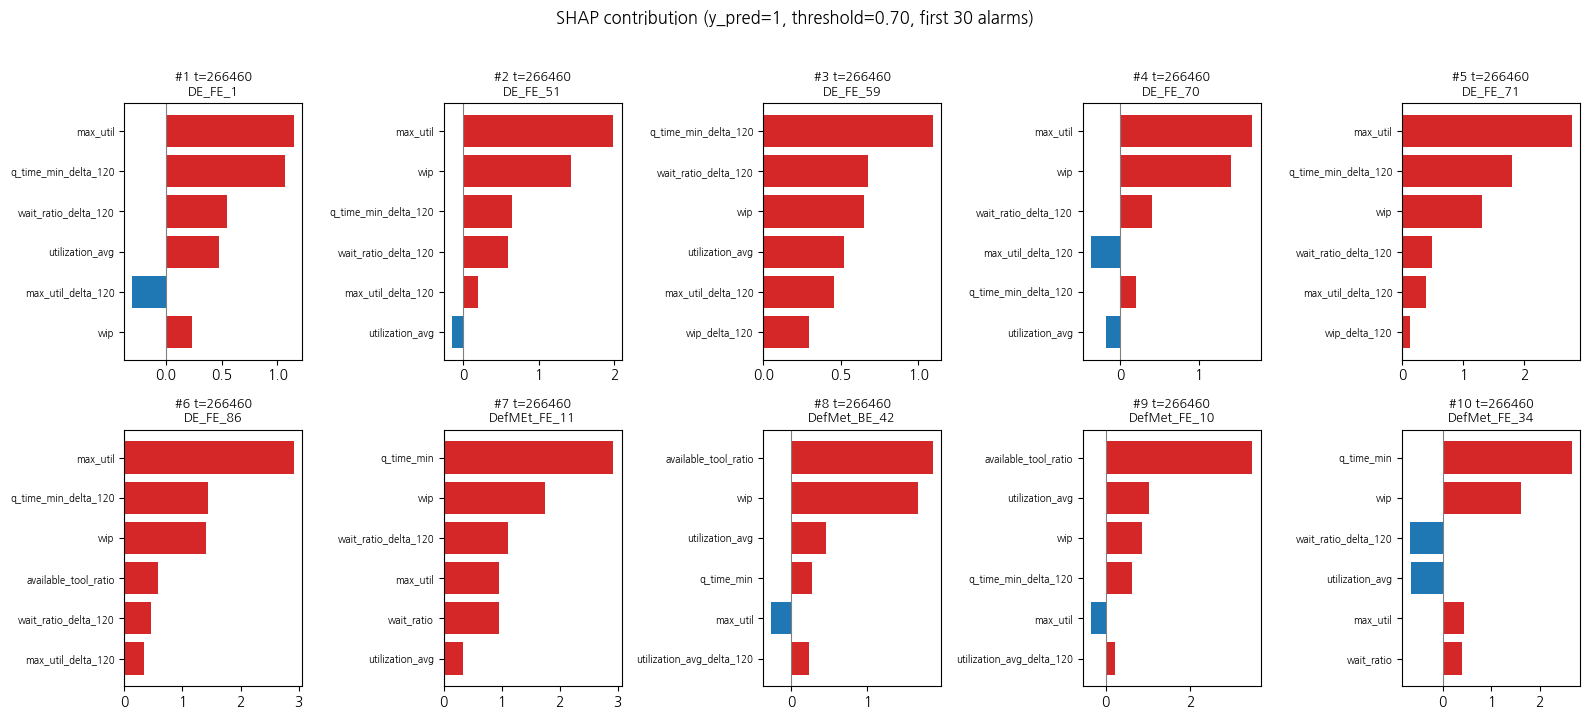

/Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simulation/.venv/lib/python3.14/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simulation/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


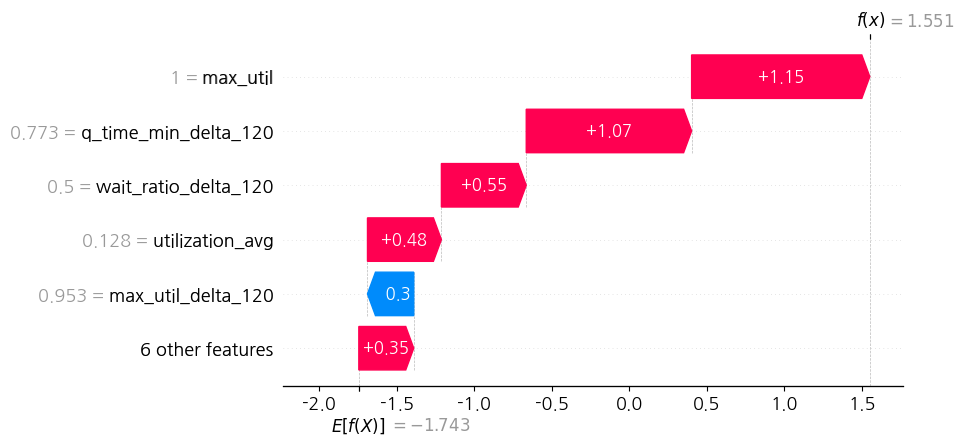

In [29]:
# §9 SHAP — test에서 병목으로 예측된 처음 10건의 피처 기여도

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import shap
except ImportError as e:
    raise ImportError(
        "shap 패키지가 없습니다. FAB_BEAR simulation venv에서: pip install shap"
    ) from e

for _name in (
    "model",
    "X_train",
    "X_test",
    "df_test",
    "FEATURE_COLS",
    "ALARM_PROBA_THRESHOLD",
):
    assert _name in dir(), f"먼저 §8·§8-1을 실행하세요. (missing: {_name})"

SHAP_N_EXPLAIN = 30
SHAP_TOP_K = 6
SHAP_BG_SAMPLES = 300
SHAP_RANDOM_STATE = 42

_thr = float(ALARM_PROBA_THRESHOLD)
print(f"alarm threshold (proba): {_thr:.2f}")

# test 예측 + 메타
_proba_test = model.predict_proba(X_test)[:, 1]
_explain_base = df_test[["snapshot_time", "toolgroup", "y_bottleneck"]].copy()
_explain_base["proba"] = _proba_test
_explain_base["y_pred"] = (_proba_test >= _thr).astype(int)

_pos = (
    _explain_base[_explain_base["y_pred"] == 1]
    .sort_values(["snapshot_time", "toolgroup"], kind="mergesort")
    .head(SHAP_N_EXPLAIN)
)
if len(_pos) < SHAP_N_EXPLAIN:
    raise ValueError(
        f"병목 예측(y_pred=1) 행이 {len(_pos)}건뿐입니다 (요청 {SHAP_N_EXPLAIN}건). "
        f"임계값을 낮추거나 test 구간을 확인하세요."
    )

_pos_idx = _pos.index.to_numpy()
X_explain = X_test.loc[_pos_idx]
print(f"SHAP 대상: {len(_pos_idx)} rows (test, y_pred=1, time-ordered first {SHAP_N_EXPLAIN})")
display(
    _pos.assign(
        toolgroup_name=_pos["toolgroup"],
        minutes_ahead=120,
    )[
        [
            "snapshot_time",
            "toolgroup",
            "proba",
            "y_bottleneck",
            "y_pred",
        ]
    ]
)

# background (train subsample) — TreeExplainer 기준 분포
_bg_n = min(SHAP_BG_SAMPLES, len(X_train))
_bg_idx = (
    pd.Series(range(len(X_train)))
    .sample(n=_bg_n, random_state=SHAP_RANDOM_STATE)
    .to_numpy()
)
X_background = X_train.iloc[_bg_idx]

explainer = shap.TreeExplainer(
    model,
    data=X_background,
    feature_perturbation="interventional",
)
shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(np.asarray(base_value).ravel()[-1])
else:
    base_value = float(base_value)

# REPORT §7.2 4축 ↔ 피처 (Agent 문장용)
FEATURE_AXIS_KO: dict[str, tuple[str, str]] = {
    "q_time_min": ("혼잡", "대기시간(분)"),
    "wait_ratio": ("혼잡", "대기 비율"),
    "wip": ("혼잡", "WIP(작업량)"),
    "available_tool_ratio": ("가용", "가용 설비 비율"),
    "utilization_avg": ("가동", "TG 평균 가동률"),
    "max_util": ("가동", "설비 최대 가동률(hot-spot)"),
    "q_time_min_delta_120": ("혼잡", "대기시간 2h 변화"),
    "wait_ratio_delta_120": ("혼잡", "대기비율 2h 변화"),
    "wip_delta_120": ("혼잡", "WIP 2h 변화"),
    "max_util_delta_120": ("가동", "max_util 2h 변화"),
    "max_avg_q_time_delta_120": ("큐", "최대 큐 대기 2h 변화"),
    "toolgroup_enc": ("TG", "툴그룹 식별"),
}


def _sign_ko(shap_v: float) -> str:
    if shap_v > 0:
        return "병목 쪽으로 기여(+)"
    if shap_v < 0:
        return "병목 아님 쪽으로 기여(-)"
    return "기여 없음"


def explain_row_shap(
    row_pos: int,
    *,
    top_k: int = SHAP_TOP_K,
) -> pd.DataFrame:
    sv = np.asarray(shap_values[row_pos], dtype=float)
    xv = X_explain.iloc[row_pos]
    meta = _pos.iloc[row_pos]

    contrib = pd.DataFrame(
        {
            "feature": FEATURE_COLS,
            "shap": sv,
            "value": xv.values,
            "abs_shap": np.abs(sv),
        }
    ).sort_values("abs_shap", ascending=False)

    total_abs = contrib["abs_shap"].sum()
    contrib["share_abs"] = contrib["abs_shap"] / max(total_abs, 1e-12)
    contrib["cum_share_abs"] = contrib["share_abs"].cumsum()

    # |SHAP| 상위 top_k (누적 share_abs ≤ cum_frac 인 피처까지 포함하려면 top_k를 키우세요)
    significant = contrib.head(top_k)

    rows_out = []
    for _, r in significant.iterrows():
        feat = r["feature"]
        axis, label = FEATURE_AXIS_KO.get(feat, ("기타", feat))
        rows_out.append(
            {
                "feature": feat,
                "axis": axis,
                "label_ko": label,
                "value": r["value"],
                "shap": r["shap"],
                "share_abs_pct": round(100 * r["share_abs"], 1),
                "direction": _sign_ko(r["shap"]),
            }
        )

    out = pd.DataFrame(rows_out)
    print(
        f"\n--- [{row_pos + 1}/{SHAP_N_EXPLAIN}] "
        f"t={meta['snapshot_time']:.0f} min | TG={meta['toolgroup']} | "
        f"proba={meta['proba']:.3f} | y_true={int(meta['y_bottleneck'])} | "
        f"base_logit={base_value:.4f} ---"
    )
    display(out)
    return out


shap_detail_tables: list[pd.DataFrame] = []
for i in range(SHAP_N_EXPLAIN):
    shap_detail_tables.append(explain_row_shap(i))

# 요약 테이블 (10건 × 주요 피처)
summary_rows = []
for i in range(SHAP_N_EXPLAIN):
    meta = _pos.iloc[i]
    tbl = shap_detail_tables[i]
    top_feats = ", ".join(
        f"{r['feature']}({r['share_abs_pct']:.0f}%)"
        for _, r in tbl.head(3).iterrows()
    )
    axes = ", ".join(sorted(set(tbl["axis"].tolist())))
    summary_rows.append(
        {
            "rank": i + 1,
            "snapshot_time": meta["snapshot_time"],
            "toolgroup": meta["toolgroup"],
            "proba": round(meta["proba"], 4),
            "y_true": int(meta["y_bottleneck"]),
            "top3_shap_features": top_feats,
            "axes": axes,
        }
    )

print("\n=== SHAP 요약 (처음 10건) ===")
display(pd.DataFrame(summary_rows))

# 막대 차트: |SHAP| 상위 피처 (10건 패널)
fig, axes = plt.subplots(2, 5, figsize=(16, 7), sharex=False)
axes = axes.ravel()
for i, ax in enumerate(axes):
    meta = _pos.iloc[i]
    tbl = shap_detail_tables[i].sort_values("shap", key=np.abs, ascending=True)
    colors = ["tab:red" if v > 0 else "tab:blue" for v in tbl["shap"]]
    ax.barh(tbl["feature"], tbl["shap"], color=colors)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(
        f"#{i+1} t={meta['snapshot_time']:.0f}\n{meta['toolgroup'][:12]}",
        fontsize=9,
    )
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle(
    f"SHAP contribution (y_pred=1, threshold={_thr:.2f}, first {SHAP_N_EXPLAIN} alarms)",
    y=1.02,
)
plt.tight_layout()
plt.show()

# (선택) 단일 건 waterfall — 첫 번째 알람
try:
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[0],
            base_values=base_value,
            data=X_explain.iloc[0].values,
            feature_names=list(FEATURE_COLS),
        ),
        max_display=SHAP_TOP_K,
    )
except Exception as e:
    print("(waterfall 생략)", e)